In [1]:
import os
import pandas as pd
import numpy as np
import sys
import json
import pickle
sys.path.append("../LB")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial import cKDTree
from scipy.optimize import minimize
from nilearn import plotting
from src.decomposition import CompoThr
from src.setting import GetInfo, PROJECT_PATH
from src.config import COL_REG
from sklearn.model_selection import KFold

from scipy.stats import spearmanr

In [2]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [3]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

MEG Subject number :  32
iEEG Subject number :  30


In [4]:
from utils import get_meg_data, get_ieeg_data, match_meg
ieeg_data_mean = get_ieeg_data(ieeg_datapath, ieeg_subj_list).mean(0)*1000 # As there is a /1000 in the normalisation function of the ieEG preproc -- To remove 
meg_data_source = get_meg_data(meg_outpath, meg_subj_list)
data_matched = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list).mean(0)
data_matched_avg = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list, average_subject=True).mean(0)

In [5]:
ieeg_data=ieeg_data_mean

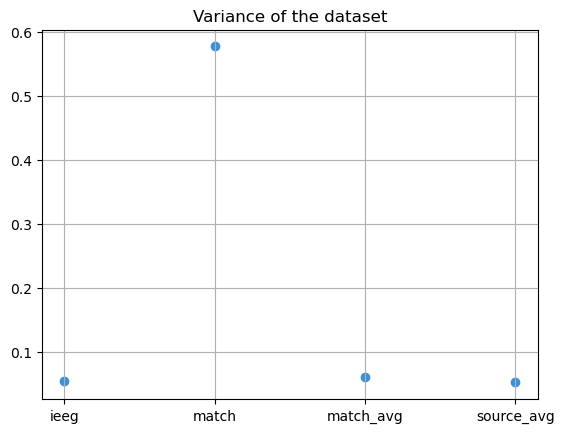

In [6]:
# variance
ieeg_var = np.sum((ieeg_data_mean - ieeg_data_mean.mean(axis=1, keepdims=True))**2) / (ieeg_data_mean.shape[1] - 1)
match_var = np.sum((data_matched - data_matched.mean(axis=1, keepdims=True))**2) / (data_matched.shape[1] - 1)
source_var = np.sum((meg_data_source.mean(0).mean(0) - meg_data_source.mean(0).mean(0).mean(axis=1, keepdims=True))**2)/(meg_data_source.shape[-1]-1)
match_avg_var = np.sum((data_matched_avg - data_matched_avg.mean(axis=1, keepdims=True))**2) / (data_matched_avg.shape[1] - 1) 
plt.title('Variance of the dataset')
plt.grid(True)
#plt.scatter(['ieeg','match', 'match_avg', 'source_avg'], [ieeg_var, match_var, match_avg_var,source_var])
plt.scatter(['ieeg','match', 'match_avg', 'source_avg'], [ieeg_var/ieeg_data_mean.shape[0], match_var/data_matched.shape[0], match_avg_var/data_matched_avg.shape[0],source_var/meg_data_source.shape[2]] )

In [7]:
# Latent Space and Kmeans
df_label  =pd.read_csv('out/labels/labels_Kmean_singlePC3.csv').drop(columns = ['Unnamed: 0'])
df_label_meg  =pd.read_csv('out/labels/labels_Kmean_MEG_match_pc.csv').drop(columns = ['Unnamed: 0'])
df_label_all=pd.read_csv('/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/labels/labels_Kmean_allPC3.csv')

## PCA only

In [8]:
pca_matched = PCA(30)
meg_match_trans = pca_matched.fit_transform(data_matched.T) 

pca_ieeg = PCA(30)
ieeg_trans = pca_ieeg.fit_transform(ieeg_data.T) 

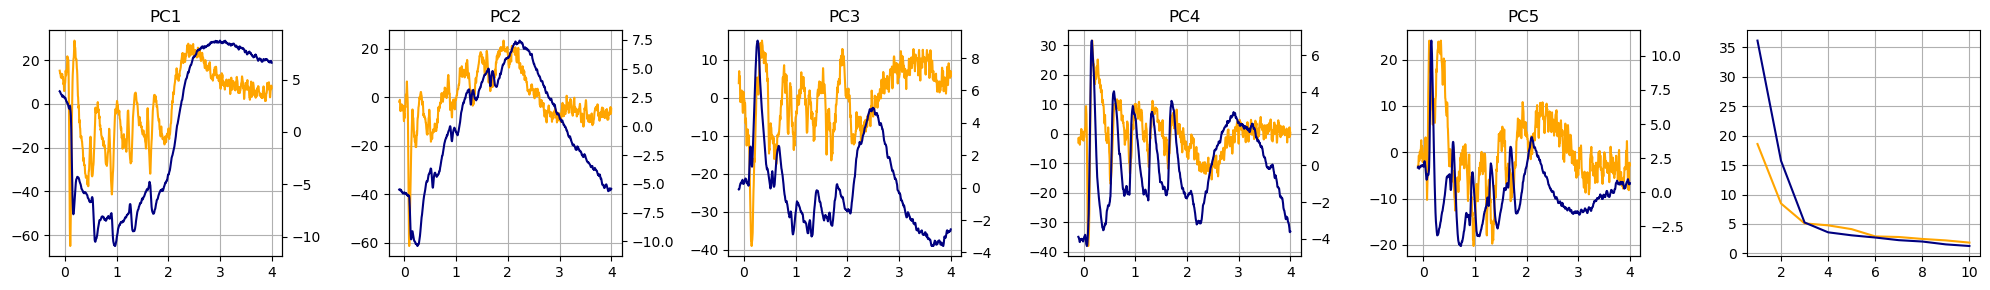

In [9]:
fig, ax = plt.subplots(1, 6, figsize=(20 , 3))

for pc in range(5) :
    ax[pc].plot(time_ieeg, meg_match_trans[:, pc], c='orange', label='meg match')
    ax2 = ax[pc].twinx()
    ax2.plot(time_ieeg, ieeg_trans[:, pc], c='navy',  label='ieeg')
    ax[pc].grid()
    ax[pc].set_title('PC' + str(pc+1))

ax[-1].plot(np.arange(1, 11, 1), pca_matched.explained_variance_ratio_[:10]*100,  c='orange', label='meg match')
ax[-1].plot(np.arange(1, 11, 1),pca_ieeg.explained_variance_ratio_[:10]*100,  c='navy',  label='ieeg')
ax[-1].grid()

fig.tight_layout()

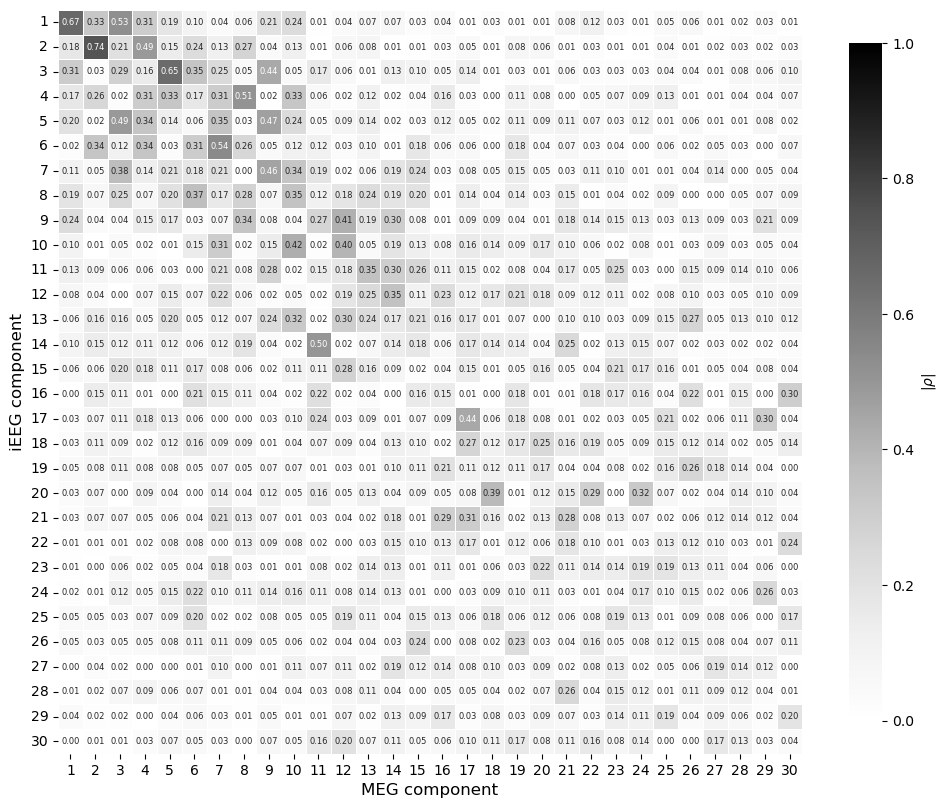

In [10]:
# check the spearman
rho = np.zeros((30, 30))
p = np.zeros((30, 30))
for pc in range(30) : 
    for pc1 in range(30) :
        rho[pc, pc1], p[pc, pc1] = spearmanr(ieeg_trans[:, pc], meg_match_trans[:, pc1])

fig, ax = plt.subplots(figsize=(12, 11))

sns.heatmap(abs(rho), cmap='Greys', vmin=0, vmax=1, square=True,
    annot=True,
     ax=ax,
    fmt=".2f",
    annot_kws={"fontsize": 6},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": r"$|\rho|$",
        "shrink": 0.8,
    })

ax.set_xlabel("MEG component", fontsize=12)
ax.set_ylabel("iEEG component", fontsize=12)

ax.set_xticklabels(range(1, 31), rotation=0)
ax.set_yticklabels(range(1, 31), rotation=0)
plt.show()

In [11]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(pca_matched.components_[pc,:].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    res.append({"dataset": 'ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})
    

    res.append({"dataset": 'meg in ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_matched.components_[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})

    res.append({"dataset": 'ieeg in meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(pca_ieeg.components_[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    
    
res_PCA= pd.DataFrame(res)

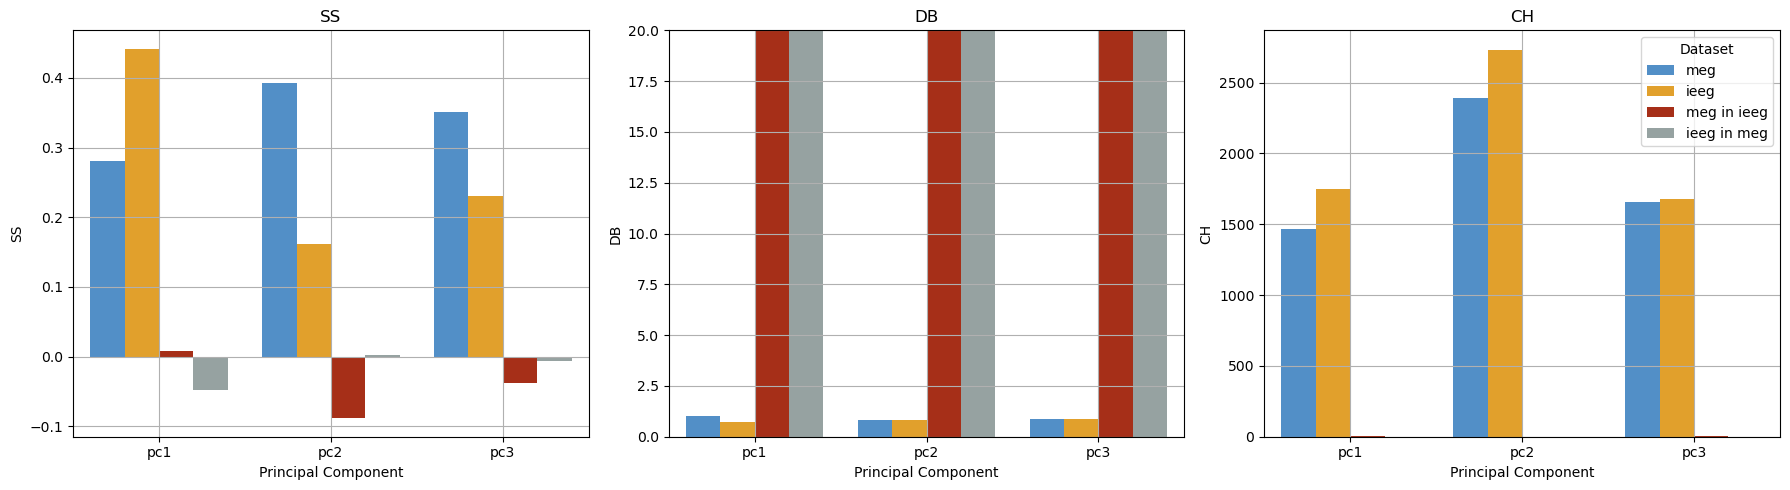

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=res_PCA,x='pc_lab',y=metric,hue='dataset',ax=ax)
    if metric == 'db' : ax.set_ylim(0, 20)
    
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper())
    ax.grid()
    ax.legend().remove()

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

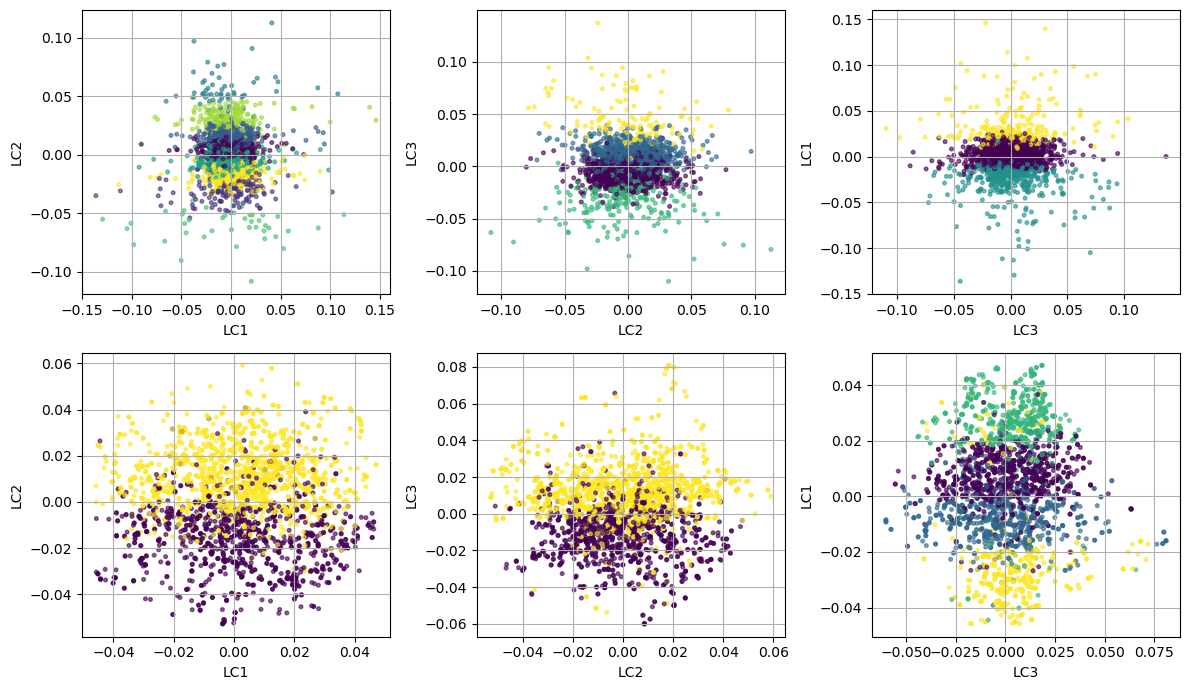

In [13]:
fig, ax=plt.subplots(2, 3, figsize=(12, 7))

for a in ax.flatten():
    a.grid()
for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(pca_ieeg.components_[i, :], pca_ieeg.components_[j, :], s=7, alpha = 0.6, c=df_label[f'ieeg_pc{j}'].values)
    ax[1][axi].scatter(pca_matched.components_[i, :], pca_matched.components_[j, :], s=7, alpha = 0.6,c= df_label_meg[f'meg_pc{j}'].values)
    for k in range(2):
        ax[k][axi].set_ylabel(f'LC{j+1}')
        ax[k][axi].set_xlabel(f'LC{i+1}')

plt.tight_layout()

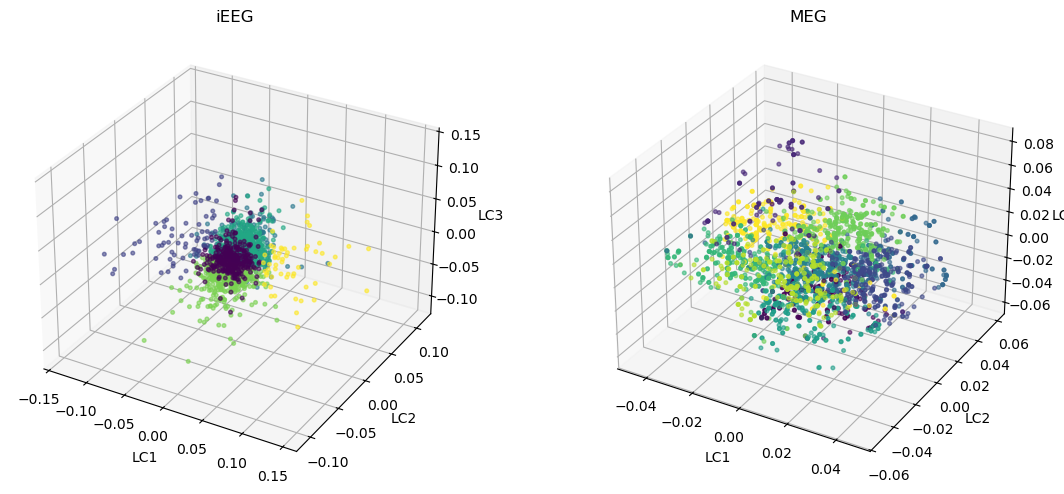

In [14]:

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(pca_ieeg.components_[0, :],pca_ieeg.components_[1, :],pca_ieeg.components_[2, :],s=7,alpha=0.6,c=df_label_all['ieeg'].values)
ax1.set_xlabel('LC1')
ax1.set_ylabel('LC2')
ax1.set_zlabel('LC3')
ax1.set_title('iEEG')
ax1.grid(True)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(pca_matched.components_[0, :],pca_matched.components_[1, :],pca_matched.components_[2, :],s=7,alpha=0.6,c=df_label_all['meg'].values)
ax2.set_xlabel('LC1')
ax2.set_ylabel('LC2')
ax2.set_zlabel('LC3')
ax2.set_title('MEG')
ax2.grid(True)

plt.tight_layout()
plt.show()

## PCA JOINT

In [15]:
nb_compo = 60

pca_join_ = PCA(nb_compo)
X= np.concat([ieeg_data, data_matched],axis=0 )
join_transform = pca_join_.fit_transform(X.T)

Wx = pca_join_.components_[:, :ieeg_data.shape[0]]
Wy = pca_join_.components_[:, ieeg_data.shape[0]:]

X_trans = Wx @ ieeg_data
Y_trans = Wy @ data_matched

n_samples = ieeg_data.shape[1]

total_var = (np.sum(ieeg_data ** 2) +np.sum(data_matched ** 2)) / (n_samples - 1)
varx = np.diag(Wx @ ieeg_data @ ieeg_data.T @ Wx.T) / (n_samples - 1)
vary = np.diag(Wy @ data_matched @ data_matched.T @ Wy.T) / (n_samples - 1)
cross = np.sum(X_trans * Y_trans,axis=1) / (n_samples - 1)

cv_norm =cross/total_var
varx_norm = varx / total_var
vary_norm = vary / total_var

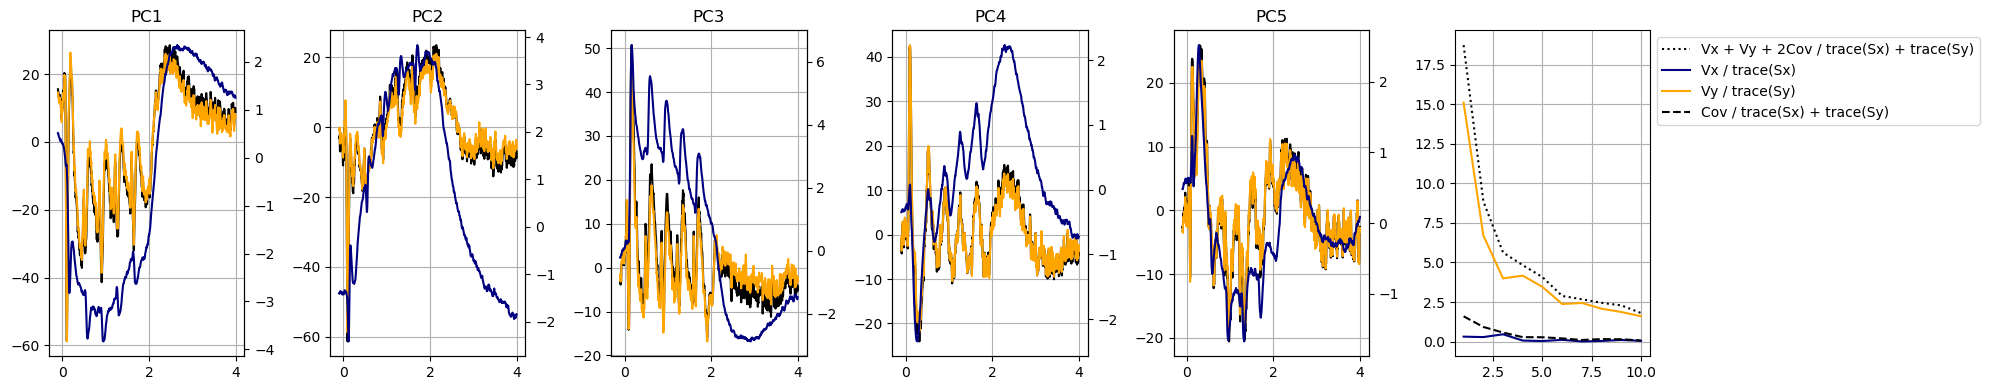

In [16]:
fig, ax = plt.subplots(1, 6, figsize=(20 , 4))

for pc in range(5) :
    ax[pc].plot(time_ieeg, join_transform[:, pc], c='k', label='joint')
    ax2 = ax[pc].twinx()
    ax2.plot(time_ieeg, X_trans.T[:, pc], c='navy', label='ieeg')
    ax[pc].plot(time_ieeg, Y_trans.T[:, pc], c='orange', label='meg')
    ax[pc].grid()
    ax[pc].set_title('PC' + str(pc+1))


ax[-1].plot(np.arange(1, 11, 1), pca_join_.explained_variance_ratio_[:10]*100,  c='k',ls=':', label='Vx + Vy + 2Cov / trace(Sx) + trace(Sy)')
ax[-1].plot(np.arange(1, 11, 1), varx_norm[:10]*100,  c='navy', label='Vx / trace(Sx)')
ax[-1].plot(np.arange(1, 11, 1), vary_norm[:10]*100,  c='orange', label='Vy / trace(Sy)')
ax[-1].plot(np.arange(1, 11, 1), cv_norm[:10]*100,  c='k',ls='--', label='Cov / trace(Sx) + trace(Sy)')
ax[-1].legend(bbox_to_anchor=(1, 1))
ax[-1].grid()

fig.tight_layout()

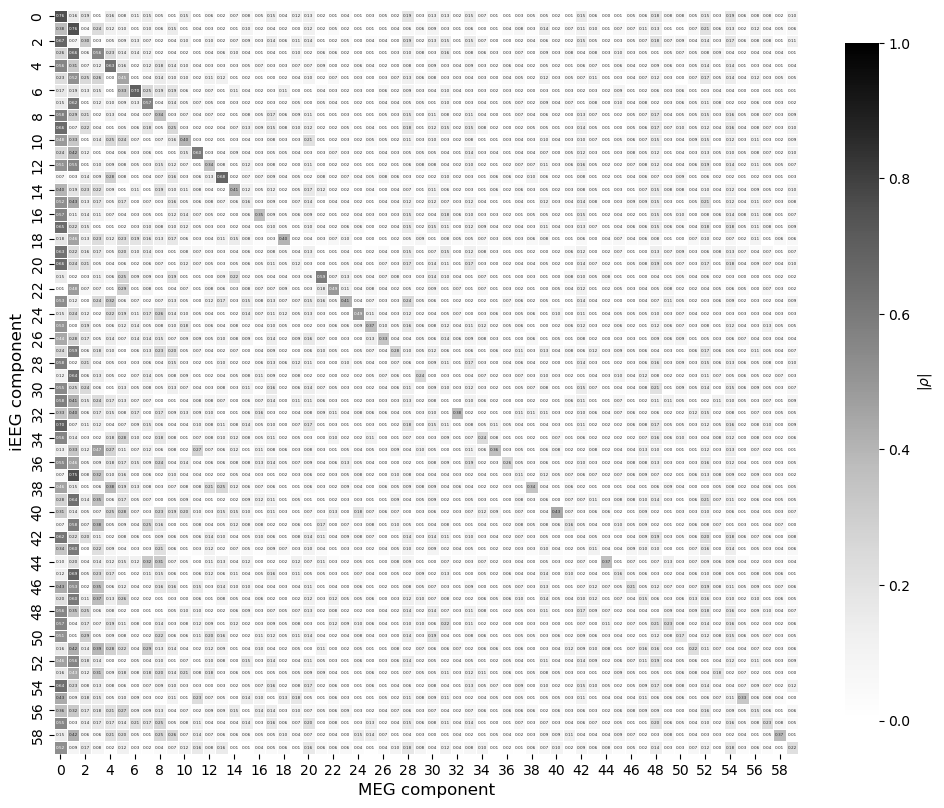

In [17]:
# check the spearman
rho = np.zeros((nb_compo, nb_compo))
p = np.zeros((nb_compo, nb_compo))
for pc in range(nb_compo) : 
    for pc1 in range(nb_compo) :
        rho[pc, pc1], p[pc, pc1] = spearmanr(X_trans.T[:, pc], Y_trans.T[:, pc1])

fig, ax = plt.subplots(figsize=(12, 11))

sns.heatmap(abs(rho), cmap='Greys', vmin=0, vmax=1, square=True,
    annot=True,
     ax=ax,
    fmt=".2f",
    annot_kws={"fontsize": 3},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": r"$|\rho|$",
        "shrink": 0.8,
    })

ax.set_xlabel("MEG component", fontsize=12)
ax.set_ylabel("iEEG component", fontsize=12)

plt.show()

In [18]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc,:].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    res.append({"dataset": 'ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})
    

    res.append({"dataset": 'meg in ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})

    res.append({"dataset": 'ieeg in meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})

res_PCA_joint= pd.DataFrame(res)

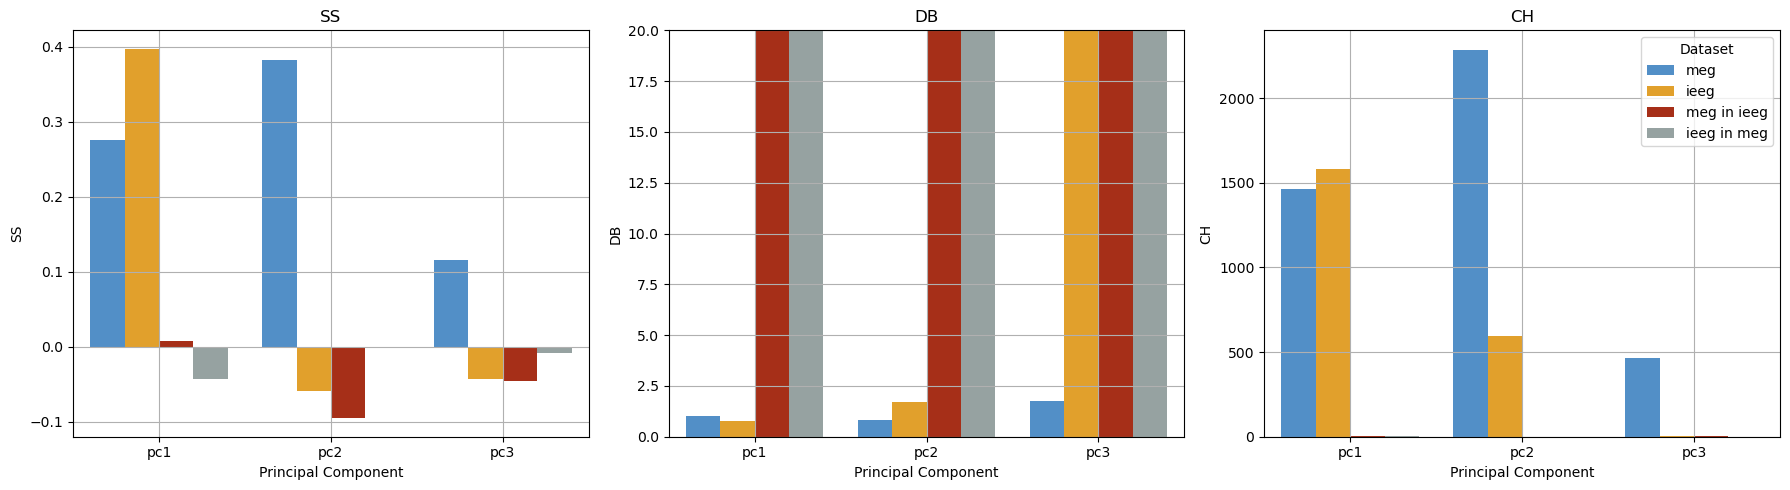

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=res_PCA_joint,
        x='pc_lab',
        y=metric,
        hue='dataset',
        ax=ax
    )
    
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper())
    ax.grid()
    ax.legend().remove()
    if metric == 'db' : ax.set_ylim(0, 20)

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

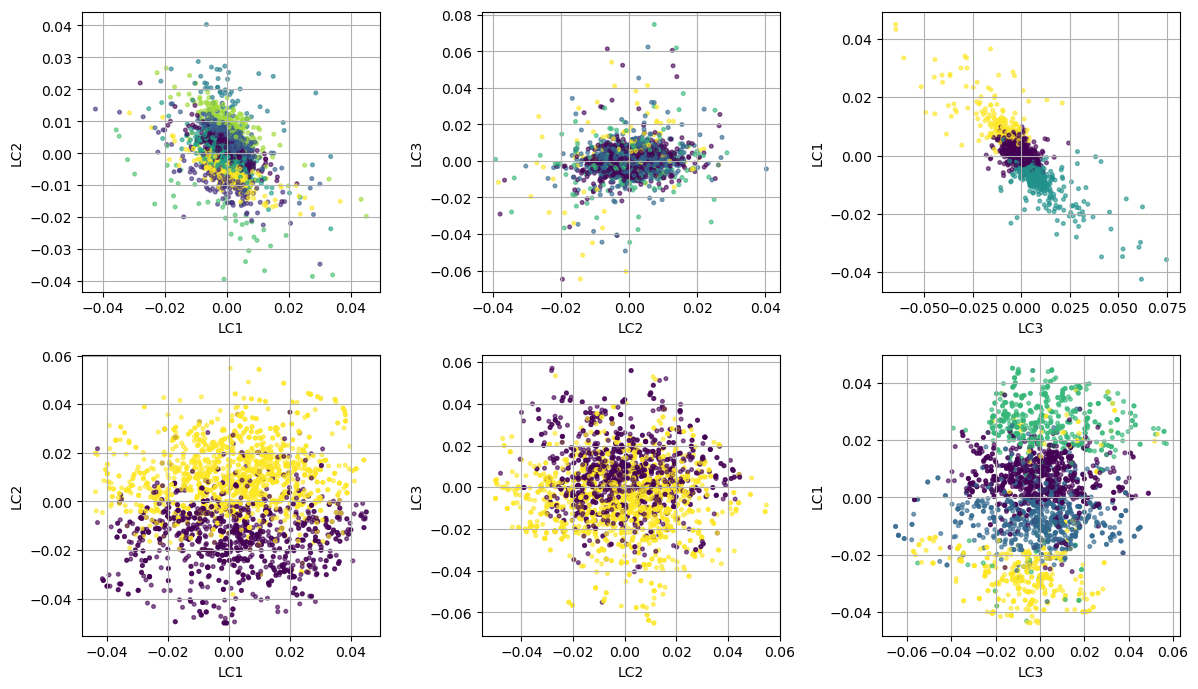

In [20]:
fig, ax=plt.subplots(2, 3, figsize=(12, 7))
for a in ax.flatten():
    a.grid()

for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(Wx[i, :], Wx[j, :], s=7, alpha = 0.6, c=df_label[f'ieeg_pc{j}'].values)
    ax[1][axi].scatter(Wy[i, :], Wy[j, :], s=7, alpha = 0.6,c= df_label_meg[f'meg_pc{j}'].values)
    for k in range(2):
        ax[k][axi].set_ylabel(f'LC{j+1}')
        ax[k][axi].set_xlabel(f'LC{i+1}')

plt.tight_layout()

In [21]:
nb_compo=200
model='PLSSVD'
scaled_ = False

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_model.p'
with open(file, "rb") as f:
    cca_model = pickle.load(f)

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_X.p'
with open(file, "rb") as f:
    Xcca = pickle.load(f)

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_Y.p'
with open(file, "rb") as f:
    Ycca = pickle.load(f)

Wx = cca_model.x_weights_.T
Wy = cca_model.y_weights_.T

n_samples = ieeg_data.shape[1]

# Total variance
total_var = (np.sum(ieeg_data ** 2) +np.sum(data_matched ** 2)) / (n_samples - 1)
varx = np.diag(Wx @ ieeg_data @ ieeg_data.T @ Wx.T) / (n_samples - 1)
vary = np.diag(Wy @ data_matched @ data_matched.T @ Wy.T) / (n_samples - 1)
X_latent = Wx @ ieeg_data
Y_latent = Wy @ data_matched
cross = np.sum(X_latent * Y_latent,axis=1) / (n_samples - 1)
cv = cross
varx_norm = varx / total_var
vary_norm = vary / total_var
cv_norm = cv / total_var

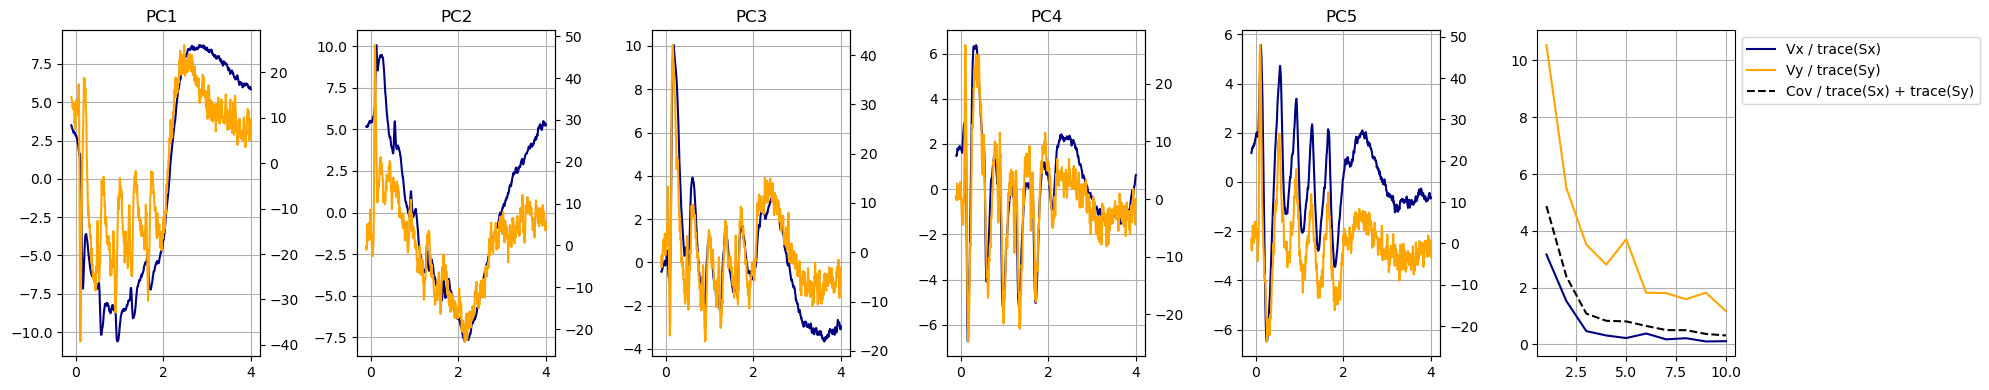

In [22]:
fig, ax = plt.subplots(1, 6, figsize=(20 , 4))

for pc in range(5) :
    ax[pc].plot(time_ieeg, Xcca[:, pc], c='navy', label='ieeg')
    ax2 = ax[pc].twinx()
    ax2.plot(time_ieeg, Ycca[:, pc], c='orange',  label='meg match')
    
    ax[pc].grid()
    ax[pc].set_title('PC' + str(pc+1))


ax[-1].plot(np.arange(1, 11, 1 ), varx_norm[:10]*100,  c='navy', label='Vx / trace(Sx)')
ax[-1].plot(np.arange(1, 11, 1 ),vary_norm[:10]*100,  c='orange', label='Vy / trace(Sy)')
ax[-1].plot(np.arange(1, 11, 1 ),cv_norm[:10]*100,  c='k',ls='--', label='Cov / trace(Sx) + trace(Sy)')
ax[-1].legend(bbox_to_anchor=(1, 1))
ax[-1].grid()
fig.tight_layout()

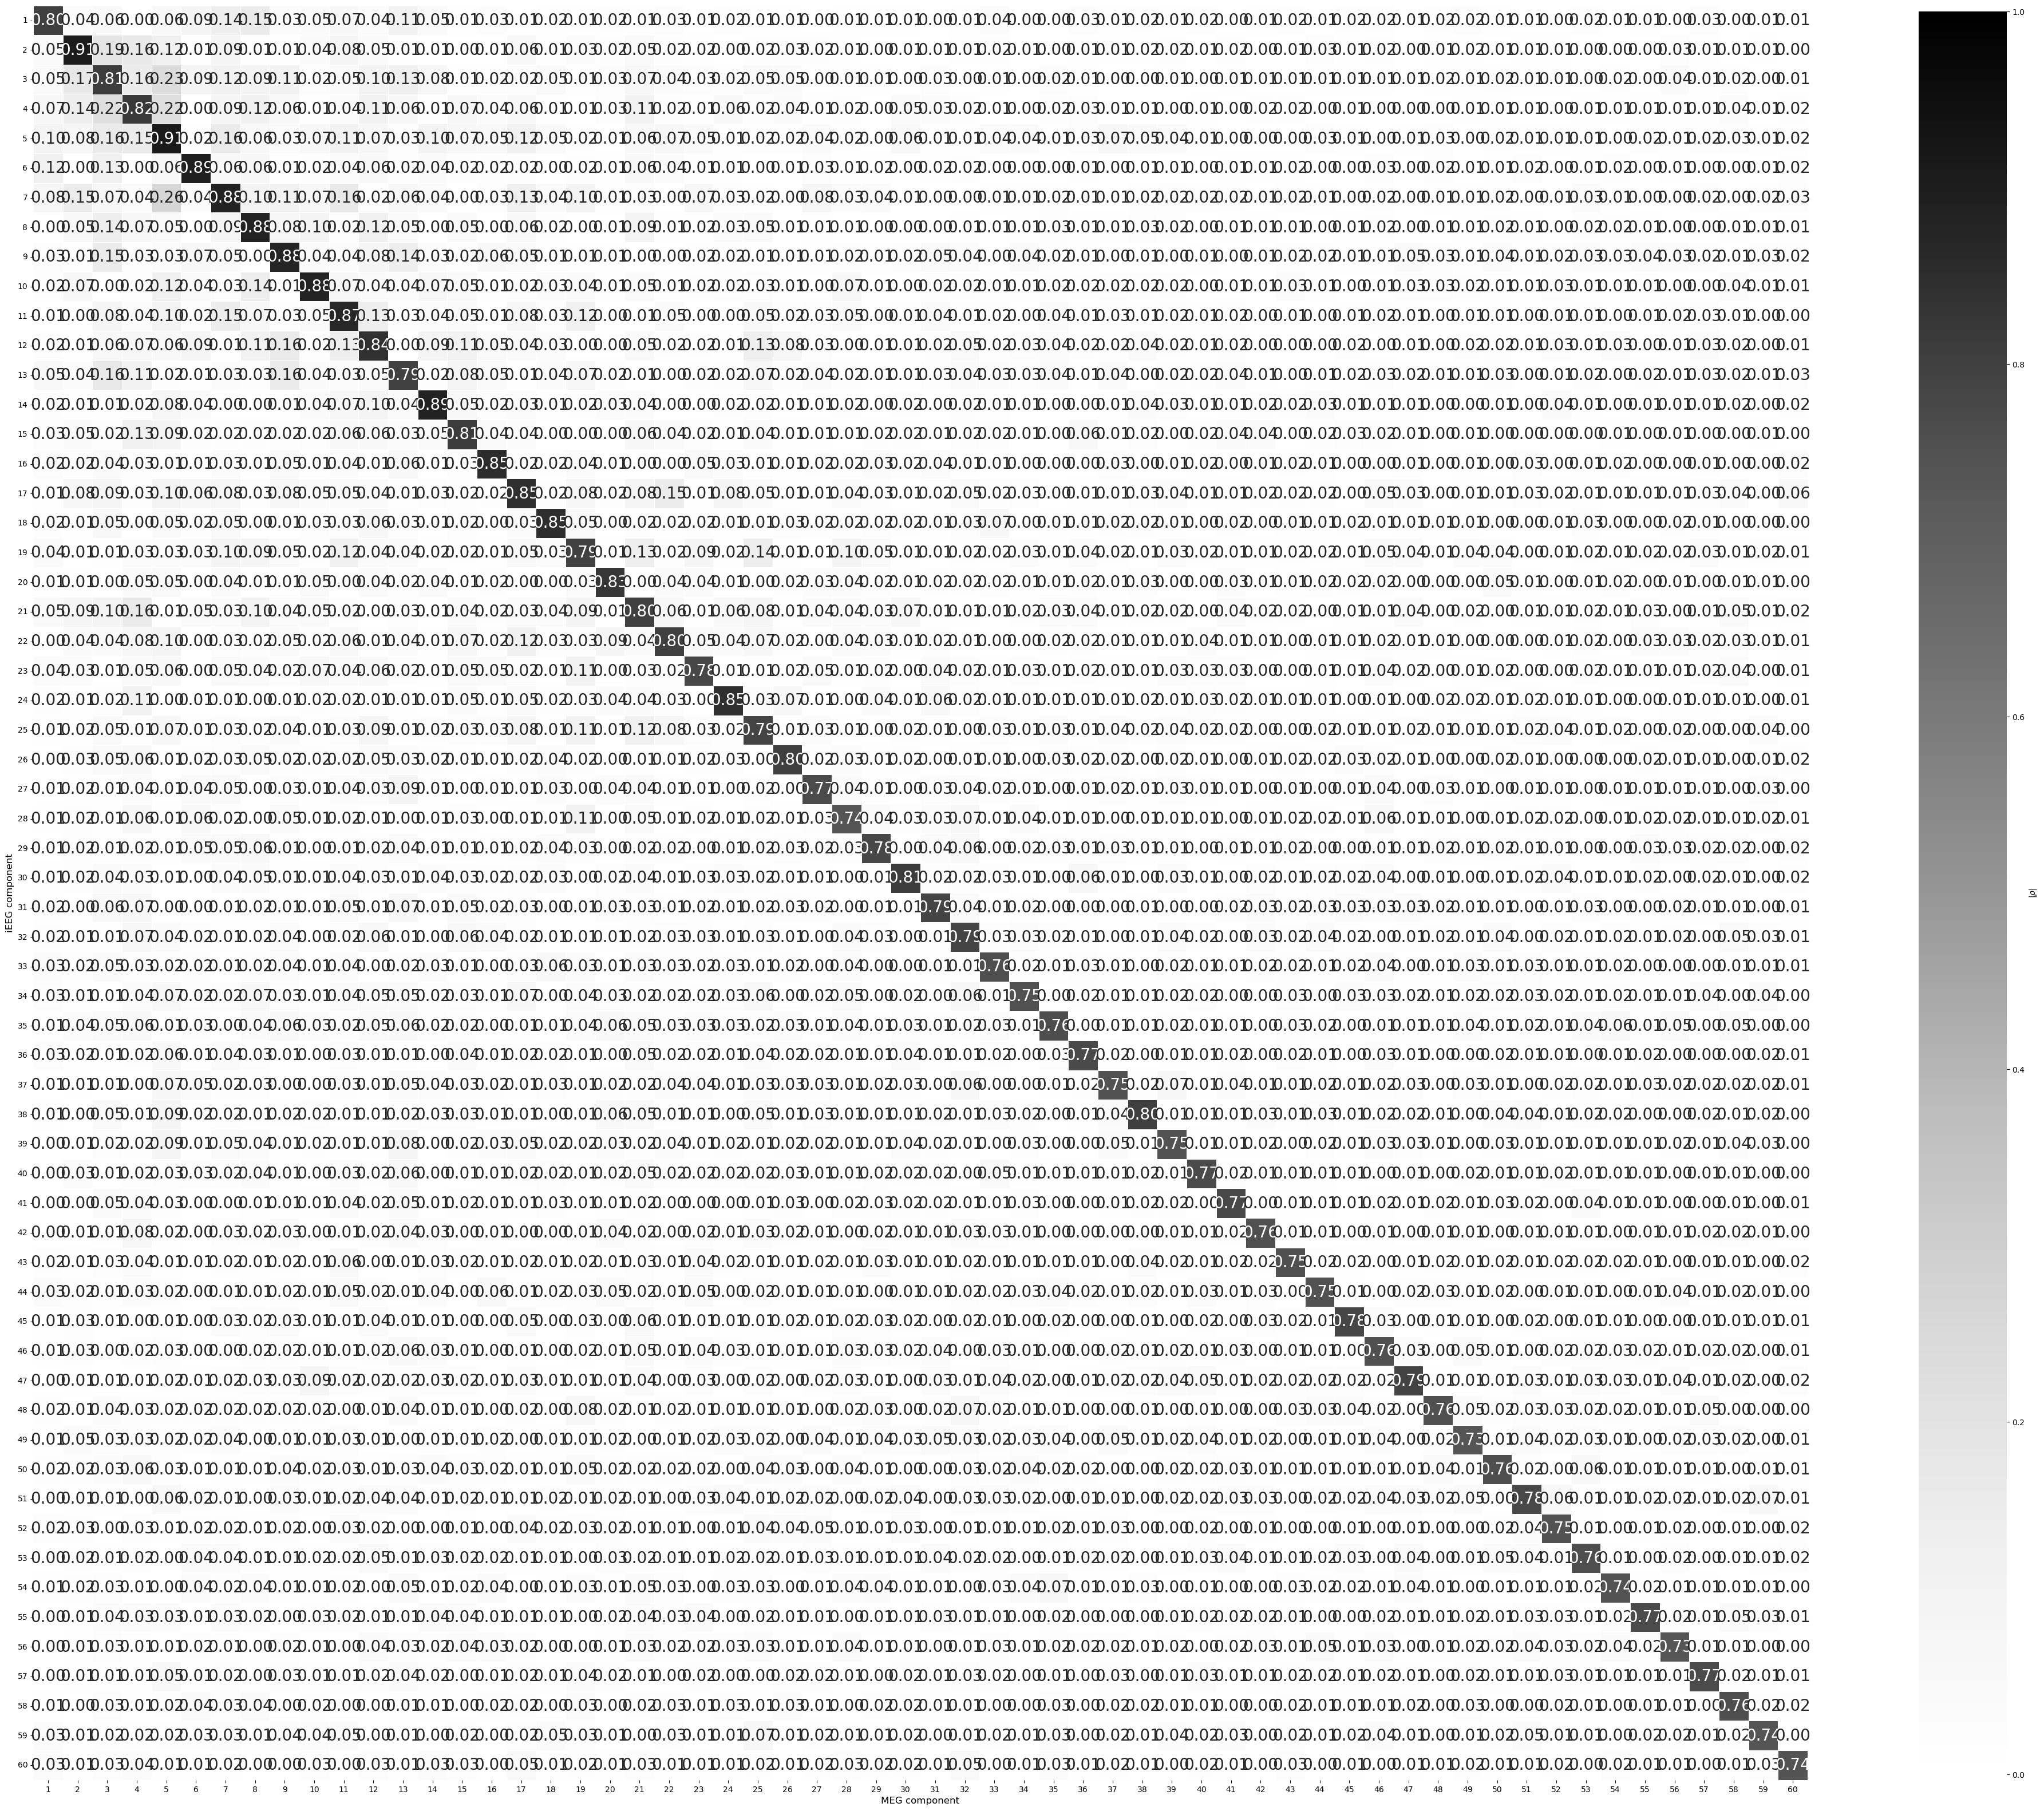

In [23]:
# check the spearman
nb_compo=60
rho = np.zeros((nb_compo, nb_compo))
p = np.zeros((nb_compo, nb_compo))
for pc in range(nb_compo) : 
    for pc1 in range(nb_compo) :
        rho[pc, pc1], p[pc, pc1] = spearmanr(Xcca[:, pc], Ycca[:, pc1])

fig, ax = plt.subplots(figsize=(50, 50))

sns.heatmap(abs(rho), cmap='Greys', vmin=0, vmax=1, square=True,
    annot=True,
     ax=ax,
    fmt=".2f",
    annot_kws={"fontsize": 20},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": r"$|\rho|$",
        "shrink": 0.8,
    })

ax.set_xlabel("MEG component", fontsize=12)
ax.set_ylabel("iEEG component", fontsize=12)

ax.set_xticklabels(range(1, nb_compo+1), rotation=0)
ax.set_yticklabels(range(1, nb_compo+1), rotation=0)
plt.show()

In [24]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc,:].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    res.append({"dataset": 'ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})

    res.append({"dataset": 'meg in ieeg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "db": davies_bouldin_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wy[pc, :].reshape(-1, 1), df_label[f"ieeg_pc{pc}"])})

    res.append({"dataset": 'ieeg in meg',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "db": davies_bouldin_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"]),
                "ch": calinski_harabasz_score(Wx[pc, :].reshape(-1, 1), df_label_meg[f"meg_pc{pc}"])})
    
    
res_PLS= pd.DataFrame(res)

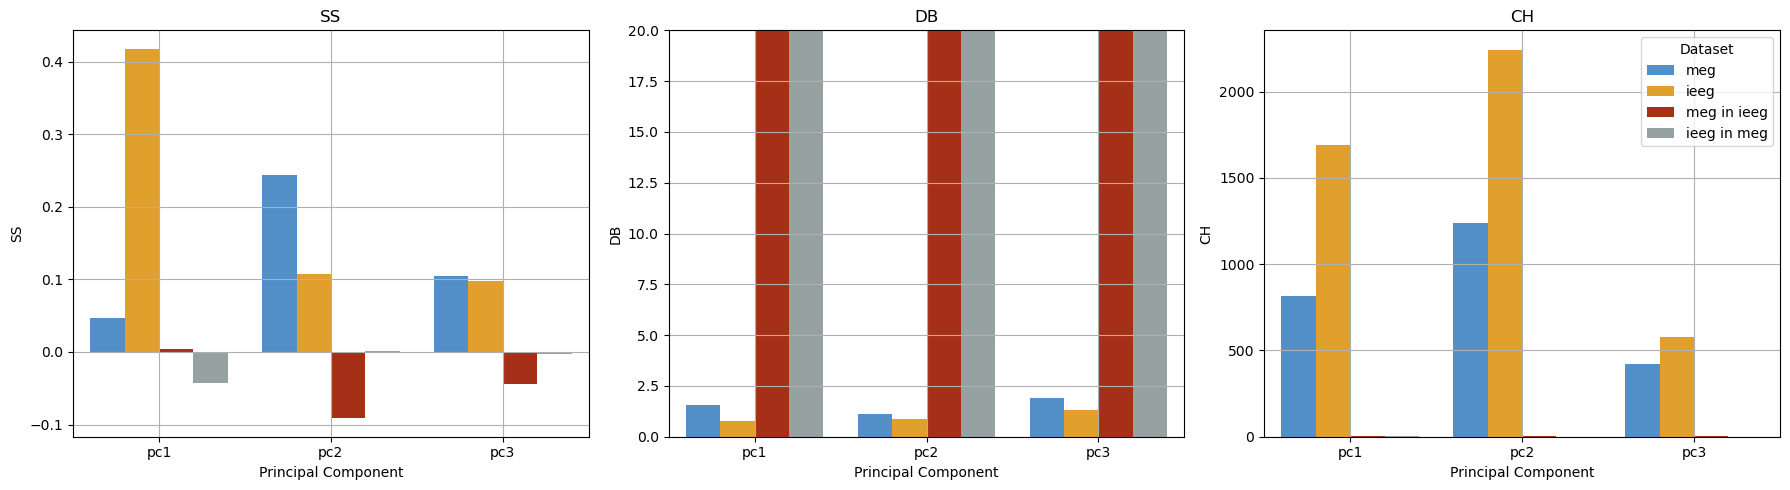

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=res_PLS,
        x='pc_lab',
        y=metric,
        hue='dataset',
        ax=ax
    )
    if metric == 'db' : ax.set_ylim(0, 20)
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper())
    ax.grid()
    ax.legend().remove()

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

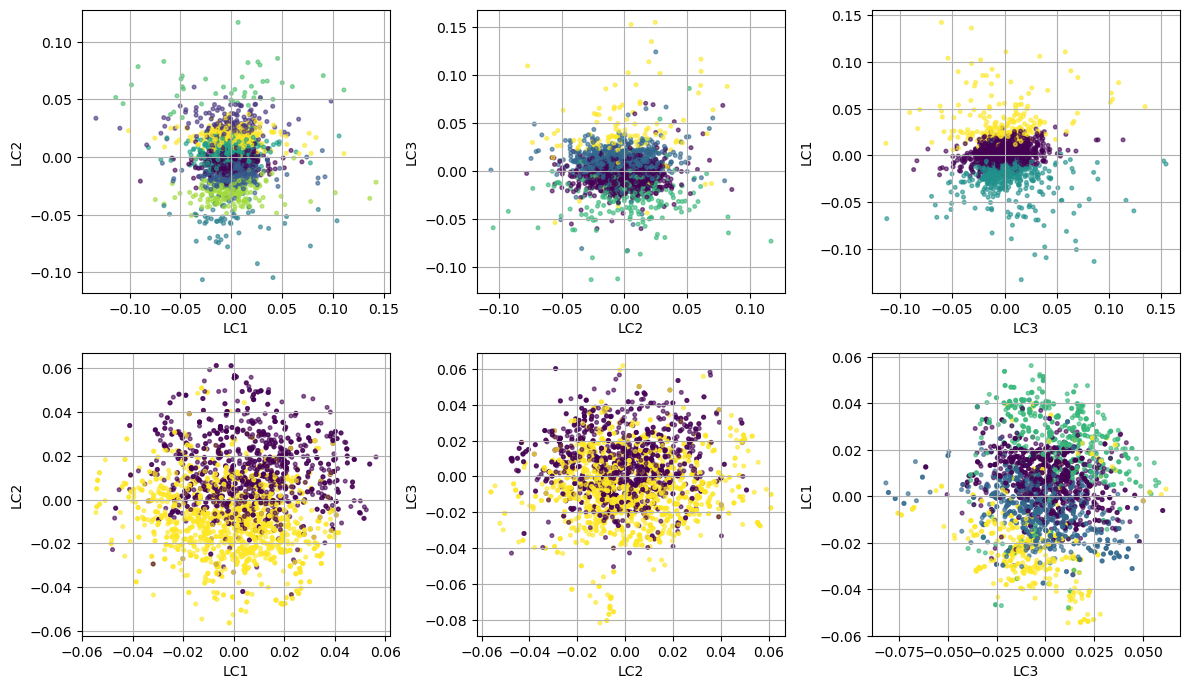

In [26]:
fig, ax=plt.subplots(2, 3, figsize=(12, 7))
for a in ax.flatten():
    a.grid()

thr_y = Wy
thr_x = Wx

for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(thr_x[i, :], thr_x[j, :], s=7, alpha = 0.6, c=df_label[f'ieeg_pc{j}'].values)
    ax[1][axi].scatter(thr_y[i, :], thr_y[j, :], s=7, alpha = 0.6,c= df_label_meg[f'meg_pc{j}'].values)
    for k in range(2):
        ax[k][axi].set_ylabel(f'LC{j+1}')
        ax[k][axi].set_xlabel(f'LC{i+1}')

plt.tight_layout()

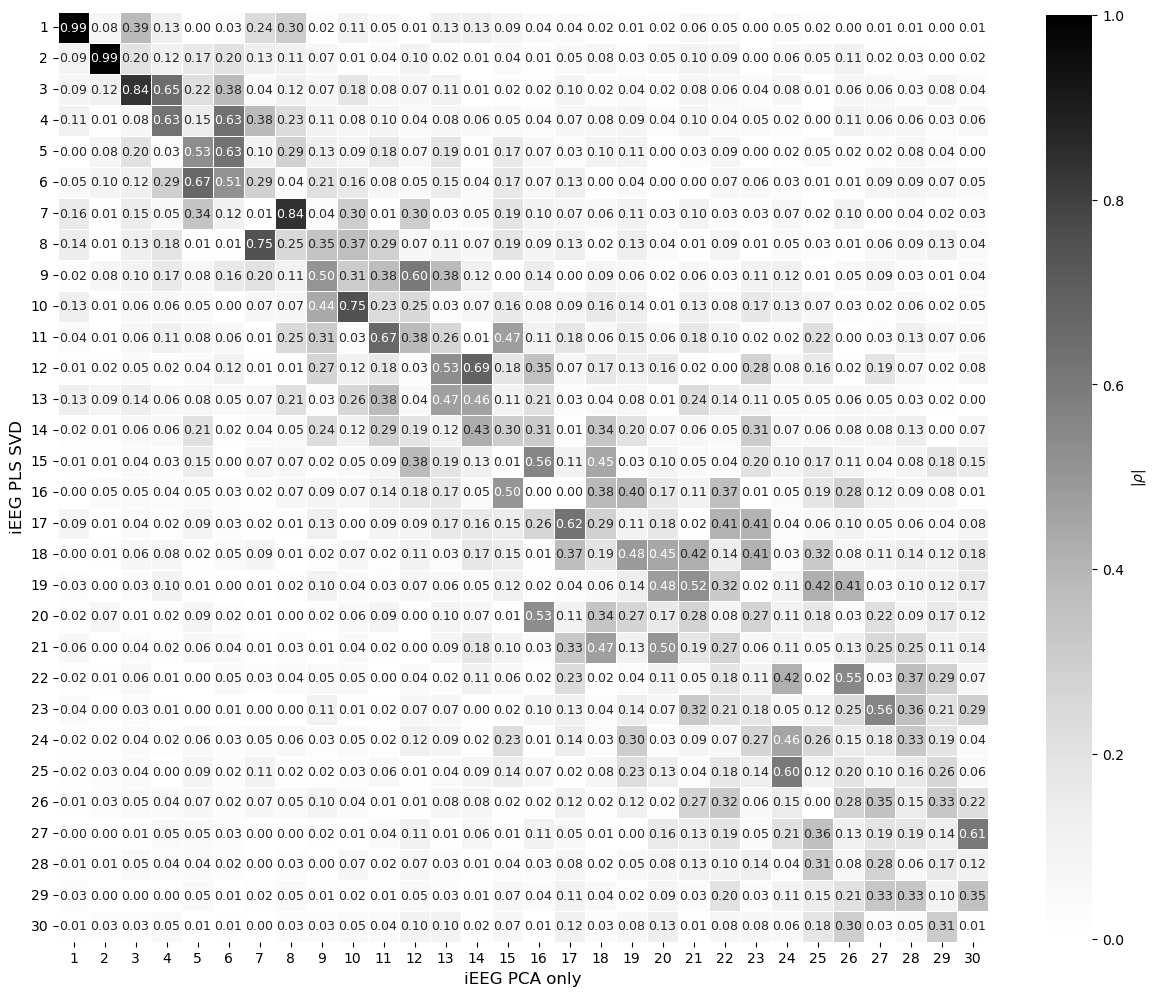

In [27]:
nb_compo=30
rho = np.zeros((nb_compo, nb_compo))
p = np.zeros((nb_compo, nb_compo))
for pc in range(nb_compo) : 
    for pc1 in range(nb_compo) :
        rho[pc, pc1], p[pc, pc1] = spearmanr(ieeg_trans[:, pc], Xcca[:, pc1])

fig, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(abs(rho), cmap='Greys', vmin=0, vmax=1, square=True,
    annot=True,
     ax=ax,
    fmt=".2f",
    annot_kws={"fontsize": 9},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": r"$|\rho|$",
        "shrink": 0.8,
    })

ax.set_xlabel("iEEG PCA only", fontsize=12)
ax.set_ylabel("iEEG PLS SVD", fontsize=12)

ax.set_xticklabels(range(1, nb_compo+1), rotation=0)
ax.set_yticklabels(range(1, nb_compo+1), rotation=0)
plt.show()

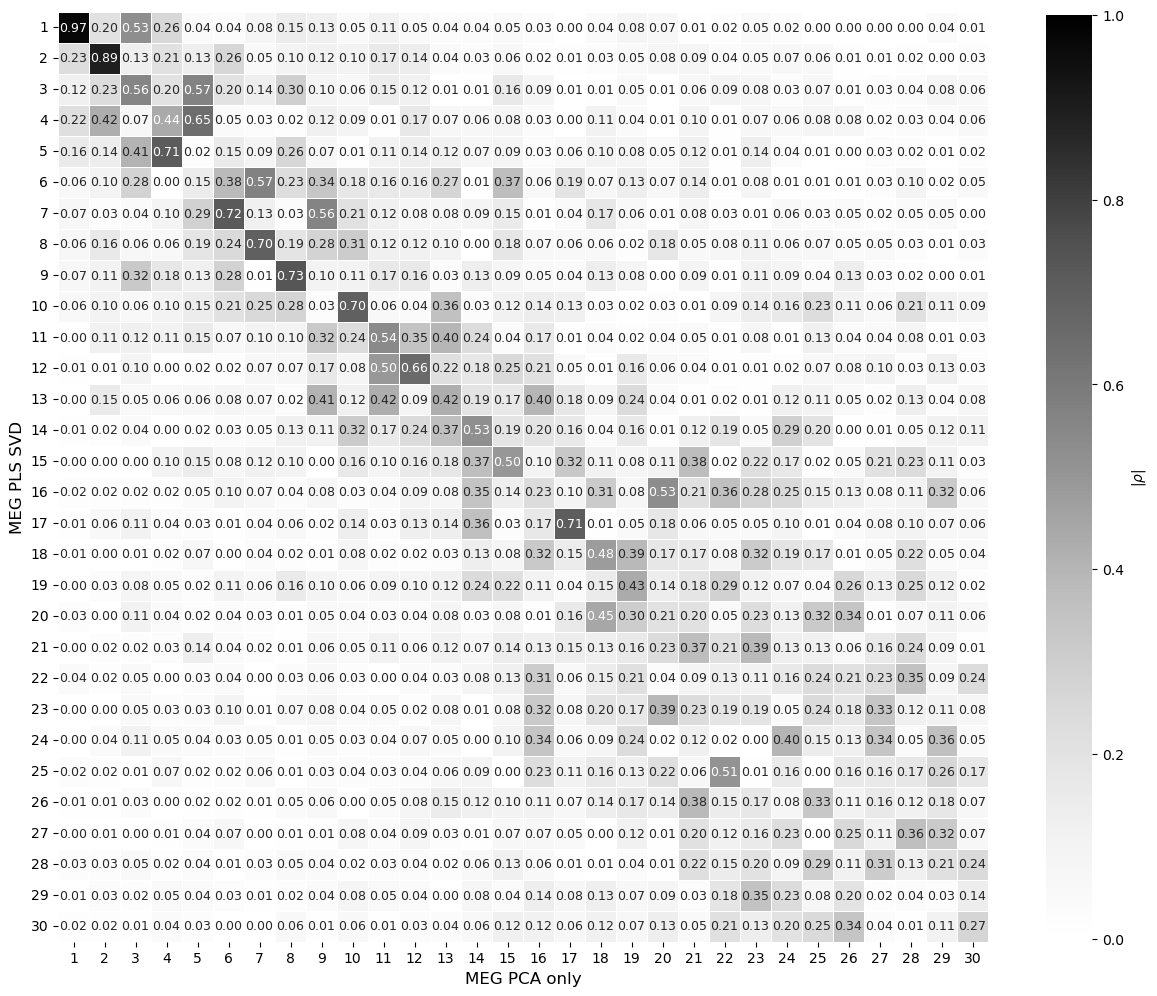

In [28]:
nb_compo=30
rho = np.zeros((nb_compo, nb_compo))
p = np.zeros((nb_compo, nb_compo))
for pc in range(nb_compo) : 
    for pc1 in range(nb_compo) :
        rho[pc, pc1], p[pc, pc1] = spearmanr(meg_match_trans[:, pc], Ycca[:, pc1])

fig, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(abs(rho), cmap='Greys', vmin=0, vmax=1, square=True,
    annot=True,
     ax=ax,
    fmt=".2f",
    annot_kws={"fontsize": 9},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": r"$|\rho|$",
        "shrink": 0.8,
    })

ax.set_xlabel("MEG PCA only", fontsize=12)
ax.set_ylabel("MEG PLS SVD", fontsize=12)

ax.set_xticklabels(range(1, nb_compo+1), rotation=0)
ax.set_yticklabels(range(1, nb_compo+1), rotation=0)
plt.show()

## Transformation for paired

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [30]:
'''
df_label_meg  =pd.read_csv('out/labels/labels_Kmean_MEG_source_avg_pc.csv').drop(columns = ['Unnamed: 0'])
with open(out_path + '/meg_data_source.p', "rb") as f:
    data_source= pickle.load(f).mean(0).mean(0)
pca_meg = PCA(10)
trans_data_source = pca_meg.fit_transform(data_source.T) 
file=f'out/cross_models/cross_models_scale_False_avg_source/PLSSVD_model.p'
with open(file, "rb") as f:
    cca_model = pickle.load(f)
'''

'\ndf_label_meg  =pd.read_csv(\'out/labels/labels_Kmean_MEG_source_avg_pc.csv\').drop(columns = [\'Unnamed: 0\'])\nwith open(out_path + \'/meg_data_source.p\', "rb") as f:\n    data_source= pickle.load(f).mean(0).mean(0)\npca_meg = PCA(10)\ntrans_data_source = pca_meg.fit_transform(data_source.T) \nfile=f\'out/cross_models/cross_models_scale_False_avg_source/PLSSVD_model.p\'\nwith open(file, "rb") as f:\n    cca_model = pickle.load(f)\n'

In [31]:
gradient = plt.cm.rainbow(np.linspace(0, 1, ieeg_data.shape[0]))

In [32]:
def affine_transform(A, B): 
    '''
    rotation, scaling, shear, and potentially reflection
    '''
    M = B @ np.linalg.pinv(A)
    t = (B.mean(axis=1, keepdims=True) - M @ A.mean(axis=1, keepdims=True)).ravel()
    return M, t

def compute_metrics(y_true, y_pred):
    """
    Compute metrics for arrays of shape:
        (n_features, n_samples)
    """

    rmse = np.sqrt(np.mean((y_pred - y_true)**2, axis=0))
    value_range = (np.max(y_true, axis=0) -np.min(y_true, axis=0))
    nrmse = np.divide(rmse,value_range,out=np.zeros_like(rmse),where=value_range != 0 )
  
    mape = np.abs((y_true - y_pred) / y_true)
    mape = np.where(np.isfinite(mape),mape,np.nan)
    mape = np.nanmean(mape, axis=0)
    score = 1 / (1 + mape)

    ss_res = np.sum((y_true - y_pred)**2,axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True))**2,axis=0)
    r2 = np.divide(1 - ss_res / ss_tot,1,out=np.zeros_like(ss_res),where=ss_tot != 0)

    std_true = np.std(y_true, axis=1)
    std_pred = np.std(y_pred, axis=1)
    spread_score = np.mean(np.divide(std_pred,std_true,out=np.zeros_like(std_pred),where=std_true != 0))

    cov_true = np.cov(y_true, rowvar=False)
    cov_pred = np.cov(y_pred, rowvar=False)
    if np.ndim(cov_true) == 0:
        cov_true = np.array([[cov_true]])
        cov_pred = np.array([[cov_pred]])

    cov_ratio = (np.trace(cov_pred) /np.trace(cov_true) if np.trace(cov_true) != 0 else np.nan)

    return {"RMSE": np.nanmean(rmse),
            "NRMSE": np.nanmean(nrmse),
            "MAPE_score": np.nanmean(score),
            "R2": np.nanmean(r2),
            "Spread": spread_score,
            "Covariance_ratio": cov_ratio}

def polynomial_features(A, degree=2):
    """
    A: (3, N)
    Returns Phi: (N, n_features)
    """
    x = A[0]
    y = A[1]
    z = A[2]
    if degree == 1:
        Phi = np.column_stack([np.ones(len(x)),x,y,z])
    elif degree == 2:
        Phi = np.column_stack([np.ones(len(x)),x,y,z,x**2,y**2,z**2,x*y,x*z,y*z])
    return Phi

def non_linear_tranform(A, B, degree=2):

    X = A.T
    Y = B.T

    x = X[:, 0]
    y = X[:, 1]
    z = X[:, 2]

    if degree == 2:
        Phi = np.column_stack([np.ones(len(x)),x,y,z,x**2,y**2,z**2,x*y,x*z,y*z])
    elif degree == 1:
        Phi = np.column_stack([np.ones(len(x)),x,y,z])

    # Least-squares fit
    # Phi @ coefficients ≈ Y
    coefficients, _, _, _ = np.linalg.lstsq(Phi,Y,rcond=None)
    return coefficients, Phi

In [33]:
#pca_ieeg.components_[:3, :] #pca_join_.components_[:3, :ieeg_data.shape[0]] #cca_model.x_weights_.T[:3, :]
#pca_matched.components_[:3, :]  #pca_join_.components_[:3, ieeg_data.shape[0]:]  cca_model.y_weights_.T[:3, :]
A = pca_ieeg.components_[:3, :]
B= cca_model.y_weights_.T[:3, :]


In [34]:
# labels
df_labels = pd.DataFrame()
for pc in range(3) : 
    labs = []
    for W in [A[pc, :], B[pc, :]] :
        W = W.reshape(-1, 1)
        cluster_range = range(2, 11)
        silhouette_scores = []
        for k in cluster_range:
            kmeans = KMeans(n_clusters=k,random_state=0,n_init=10)
            labels = kmeans.fit_predict(W)
            score = silhouette_score(W, labels)
            silhouette_scores.append(score)
        optimal_k = cluster_range[np.argmax(silhouette_scores)]
        print("Number of clusters:", optimal_k)
        print("Best silhouette score:", max(silhouette_scores))
        final_model = KMeans(n_clusters=optimal_k,random_state=0,n_init=10)
        final_labels = final_model.fit_predict(W)
        labs.append(final_labels)  

    df_labels[f'A_pc{pc}'] = labs[0]
    df_labels[f'B_pc{pc}'] = labs[1]

Number of clusters: 3
Best silhouette score: 0.5517359537677136
Number of clusters: 2
Best silhouette score: 0.562661564100491
Number of clusters: 7
Best silhouette score: 0.5247337983372917
Number of clusters: 2
Best silhouette score: 0.5562772510949293
Number of clusters: 8
Best silhouette score: 0.5250841705165478
Number of clusters: 2
Best silhouette score: 0.554099386326385


In [35]:
n_samples = A.shape[1]
kf = KFold(n_splits=5,shuffle=True,random_state=42)
metrics_before = []
metrics_after = []

for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_samples))):
    A_train = A[:, train_idx]
    A_test  = A[:, test_idx]

    B_train = B[:, train_idx]
    B_test  = B[:, test_idx]
    Phi_train = polynomial_features(A_train,degree=2 )
    coefficients, _, _, _ = np.linalg.lstsq(Phi_train,B_train.T,rcond=None)
    Phi_test = polynomial_features(A_test,degree=2)
    B_est_test = (Phi_test @ coefficients).T
    metrics_before_fold = compute_metrics(B_test,A_test)
    metrics_after_fold = compute_metrics(B_test,B_est_test)
    metrics_before.append(metrics_before_fold)
    metrics_after.append(metrics_after_fold)

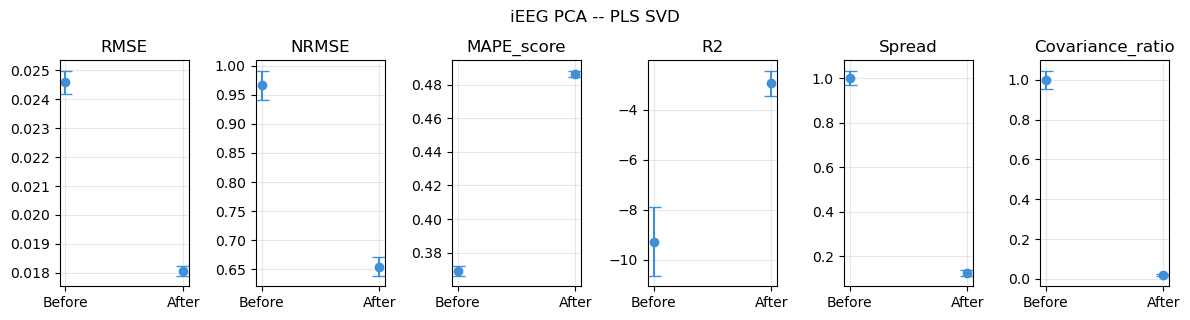

In [36]:
fig, axes = plt.subplots(1, 6,figsize=(12, 3))
metric_names = list(metrics_after[0].keys())
before_array = np.array([[metrics_before[i][name] for name in metric_names]for i in range(len(metrics_before))])
after_array = np.array([[metrics_after[i][name] for name in metric_names]for i in range(len(metrics_after))])
before_mean = np.nanmean(before_array, axis=0)
before_std  = np.nanstd(before_array, axis=0)
after_mean = np.nanmean(after_array, axis=0)
after_std  = np.nanstd(after_array, axis=0)

for i, name in enumerate(metric_names):
    ax = axes[i]
    means = [before_mean[i],after_mean[i]]
    stds = [before_std[i],after_std[i]]
    ax.errorbar([0, 1],means,yerr=stds,fmt='o',capsize=5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Before", "After"])
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.tight_layout()

fig.suptitle('iEEG PCA -- PLS SVD', y=1.05)
plt.show()

Before Total variance ratio: 1.0000000000000013
Before spread score 1.2339650032617748
Before r2 [-1.01097009 -0.9976928  -0.99007913]
Before MAPE [0.20981022 0.18357231 0.13878586]
Before NRMSE [0.25050017 0.23751695 0.19345267]
After Total variance ratio: 0.01590526586174268
After spread score 0.12516333198692522
After r2 [0.01617826 0.00433673 0.02200931]
After MAPE [0.41455945 0.46578989 0.37821356]
After NRMSE [0.17521183 0.16768202 0.13561475]


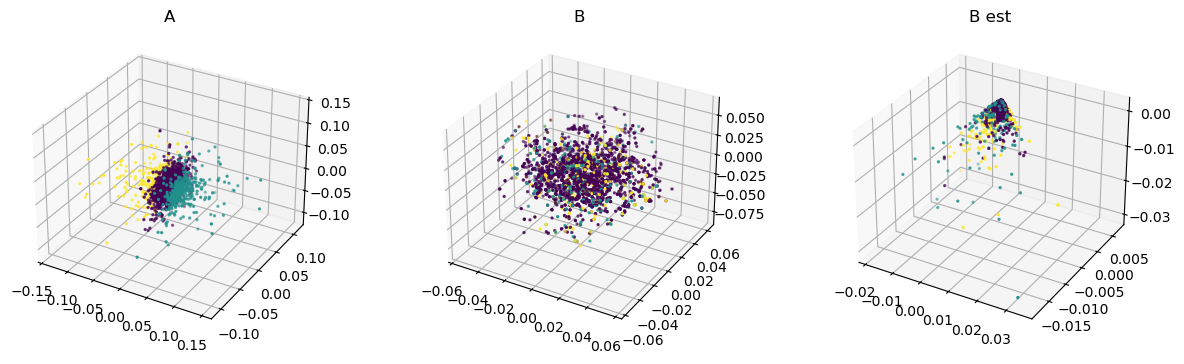

In [37]:
coefficients, Phi =  non_linear_tranform(A, B, degree=2)
B_est = (Phi @ coefficients).T
residual = B_est - B
residual_pre = A - B

cov_B = np.cov(B, rowvar=False)
cov_B_est = np.cov(B_est, rowvar=False)
cov_A = np.cov(A, rowvar=False)

rmse = np.sqrt(np.mean((A - B)**2, axis=1))
nrmse = rmse / (np.max(B, axis=1) - np.min(B, axis=1))
mape = np.mean(np.abs((B - A) / B), axis=1)
score = 1 / (1 + mape)
ss_res = np.sum((B - A)**2, axis=1)
ss_tot = np.sum((B - np.mean(B, axis=1, keepdims=True))**2, axis=1)
r2 = 1 - ss_res / ss_tot
spread_score = np.mean(np.std(A, axis=0) / np.std(B, axis=0))
cov_ratio = np.trace(cov_A) / np.trace(cov_B)
print("Before Total variance ratio:", cov_ratio)
print('Before spread score', spread_score)
print('Before r2', r2)
print('Before MAPE', score)
print('Before NRMSE', nrmse)

rmse = np.sqrt(np.mean((B_est - B)**2, axis=1))
nrmse = rmse / (np.max(B, axis=1) - np.min(B, axis=1))
mape = np.mean(np.abs((B - B_est) / B), axis=1)
score = 1 / (1 + mape)
ss_res = np.sum((B - B_est)**2, axis=1)
ss_tot = np.sum((B - np.mean(B, axis=1, keepdims=True))**2, axis=1)
r2 = 1 - ss_res / ss_tot
spread_score = np.mean(np.std(B_est, axis=0) / np.std(B, axis=0))
cov_ratio = np.trace(cov_B_est) / np.trace(cov_B)
print("After Total variance ratio:", cov_ratio)
print('After spread score', spread_score)
print('After r2', r2)
print('After MAPE', score)
print('After NRMSE', nrmse)

fig, axes = plt.subplots(1, 3,figsize=(15, 4), subplot_kw={'projection': '3d'})
axes[0].set_title('A')
axes[1].set_title('B')
axes[2].set_title('B est')

axes[0].scatter(A[0, :], A[1, :], A[2, :],  s=2,  c=df_labels[f'A_pc0'].values)
axes[1].scatter(B[ 0, :], B[1, :], B[2, :],  s=2, c=df_labels[f'A_pc0'].values)
axes[2].scatter(B_est[0, :],  B_est[1, :], B_est[2, :], s=2, c=df_labels[f'A_pc0'].values)

for a in axes: 
    a.grid()

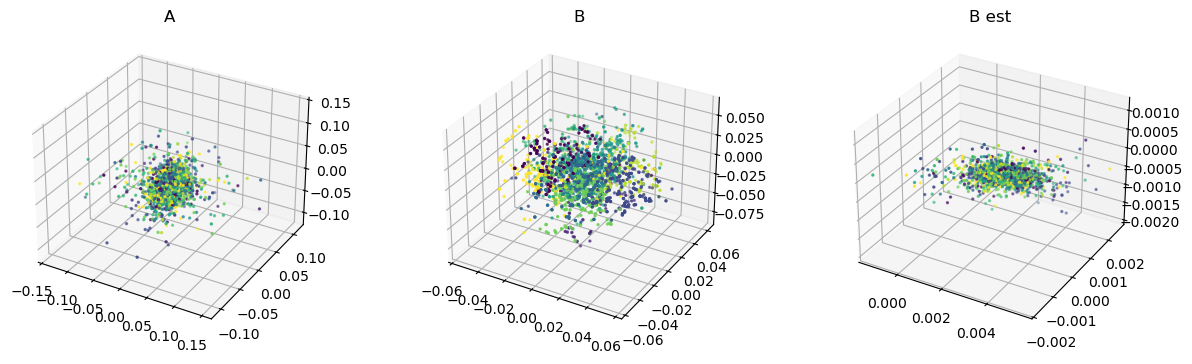

In [38]:
R, t = affine_transform(A, B)
B_est = ((R @ A).T + t).T

fig, axes = plt.subplots(1, 3,figsize=(15, 4), subplot_kw={'projection': '3d'})
axes[0].set_title('A')
axes[1].set_title('B')
axes[2].set_title('B est')

axes[0].scatter(A[0, :], A[1, :], A[2, :],  s=2,  c=df_label_all[f'meg'].values)
axes[1].scatter(B[ 0, :], B[1, :], B[2, :],  s=2, c=df_label_all[f'meg'].values)
axes[2].scatter(B_est[0, :],  B_est[1, :], B_est[2, :], s=2, c=df_label_all[f'meg'].values)

for a in axes: 
    a.grid()

In [39]:
M = np.asarray(R, dtype=float)
translation = np.asarray(t, dtype=float)
U, singular_values, Vt = np.linalg.svd(M)
det_M = np.linalg.det(M)
Q = U @ Vt
D = np.eye(3)

if np.linalg.det(Q) < 0:
    D[-1, -1] = -1
R_rotation = U @ D @ Vt
reflection_matrix = Vt.T @ D @ Vt
reflection_detected = det_M < 0
stretch_matrix = (Vt.T @ np.diag(singular_values) @ Vt)
scaling_percent = (singular_values - 1) * 100
cos_theta = (np.trace(R_rotation) - 1) / 2
cos_theta = np.clip(cos_theta,-1,1)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)
rotation_percent = (theta_deg / 180) * 100
std_data = np.std(A,axis=1,ddof=1)
std_data = np.where(std_data == 0,np.nan,std_data)
translation_percent = (np.abs(translation) / std_data) * 100
diag_stretch = np.diag(np.diag(stretch_matrix))
shear_matrix = (stretch_matrix - diag_stretch)
normalized_shear = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        if i != j:
            denom = np.sqrt(abs(stretch_matrix[i, i]* stretch_matrix[j, j]))
            if denom != 0:
                normalized_shear[i, j] = (shear_matrix[i, j]/ denom)
shear_xy = (abs(normalized_shear[0, 1]) * 100)
shear_xz = (abs(normalized_shear[0, 2]) * 100)
shear_yz = (abs(normalized_shear[1, 2]) * 100)
shear_percent = (np.linalg.norm(normalized_shear,ord="fro")/ np.sqrt(2)* 100)

df = pd.DataFrame({
    "metric": [
        "Scaling PC1",
        "Scaling PC2",
        "Scaling PC3",

        "Translation PC1",
        "Translation PC2",
        "Translation PC3",

        "Shear XY",
        "Shear XZ",
        "Shear YZ",

        "Rotation"
    ],

    "percentage": [
        abs(scaling_percent[0]),
        abs(scaling_percent[1]),
        abs(scaling_percent[2]),

        translation_percent[0],
        translation_percent[1],
        translation_percent[2],

        shear_xy,
        shear_xz,
        shear_yz,

        rotation_percent
    ]

})

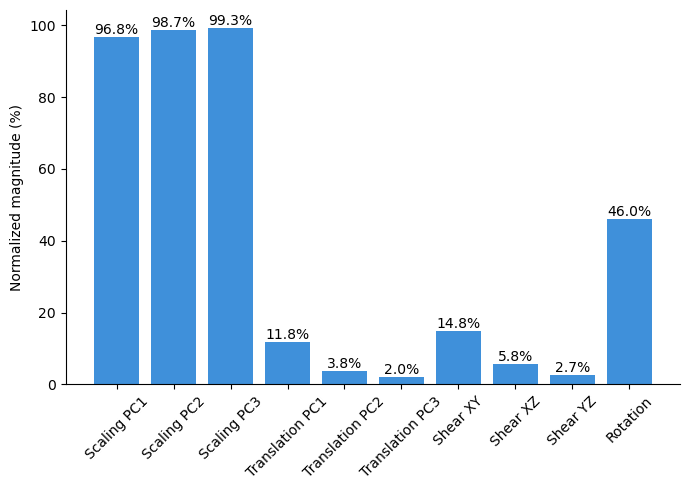

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(df['metric'],df['percentage'])
ax.set_ylabel('Normalized magnitude (%)')
ax.tick_params(axis='x', rotation=45)

# Values above bars
for bar, value in zip(bars, df['percentage']):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:.1f}%',
        ha='center',
        va='bottom'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [41]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'A',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(A[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "db": davies_bouldin_score(A[pc,:].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "ch": calinski_harabasz_score(A[pc, :].reshape(-1, 1),df_labels[f"A_pc{pc}"])})
    res.append({"dataset": 'B',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "db": davies_bouldin_score(B[pc,:].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "ch": calinski_harabasz_score(B[pc, :].reshape(-1, 1),df_labels[f"B_pc{pc}"])})
    res.append({"dataset": 'B_est with Alab',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B_est[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "db": davies_bouldin_score(B_est[pc, :].reshape(-1, 1),df_labels[f"A_pc{pc}"]),
                "ch": calinski_harabasz_score(B_est[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"])})
    res.append({"dataset": 'B_est with Blab',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "db": davies_bouldin_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "ch": calinski_harabasz_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"])})


res_PLS= pd.DataFrame(res)

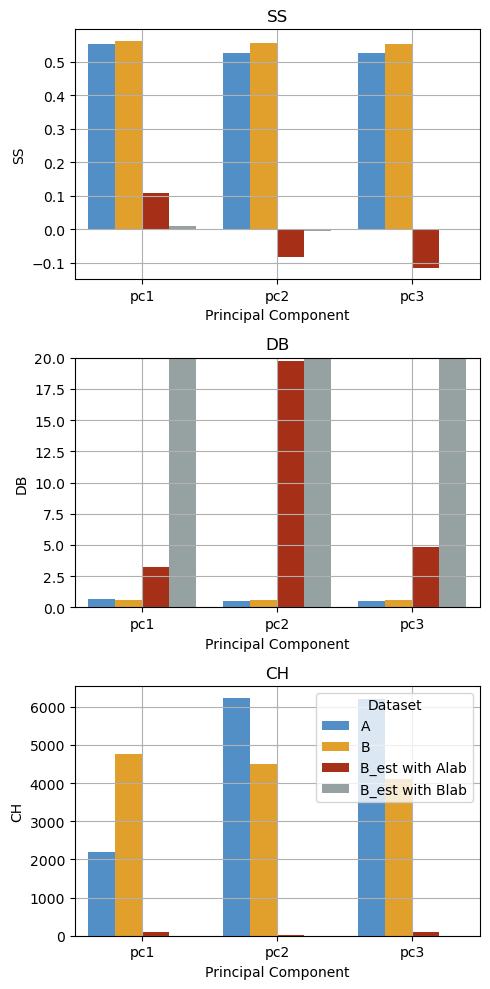

In [42]:
fig, axes = plt.subplots(3,1, figsize=(5,10))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=res_PLS,
        x='pc_lab',
        y=metric,
        hue='dataset',
        ax=ax
    )
    if metric == 'db' : ax.set_ylim(0, 20)
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper()) 
    ax.grid()
    ax.legend().remove()

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

## Transformation for unpaired

In [43]:
# A and B are paired in indices
# Once paired they A can be transformed to B -- A_transofrm = f(B[indices])
A= cca_model.x_weights_.T[:3, :] #pca_ieeg.components_[:3, :] #cca_model.x_weights_.T[:3, :]
B= cca_model.y_weights_.T[:3, :] #pca_matched.components_[:3, :] #cca_model.y_weights_.T[:3, :]

In [44]:
# labels
df_labels = pd.DataFrame()
for pc in range(3) : 
    labs = []
    for W in [A[pc, :], B[pc, :]] :
        W = W.reshape(-1, 1)
        cluster_range = range(2, 11)
        silhouette_scores = []
        for k in cluster_range:
            kmeans = KMeans(n_clusters=k,random_state=0,n_init=10)
            labels = kmeans.fit_predict(W)
            score = silhouette_score(W, labels)
            silhouette_scores.append(score)
        optimal_k = cluster_range[np.argmax(silhouette_scores)]
        print("Number of clusters:", optimal_k)
        print("Best silhouette score:", max(silhouette_scores))
        final_model = KMeans(n_clusters=optimal_k,random_state=0,n_init=10)
        final_labels = final_model.fit_predict(W)
        labs.append(final_labels)  

    df_labels[f'A_pc{pc}'] = labs[0]
    df_labels[f'B_pc{pc}'] = labs[1]

Number of clusters: 3
Best silhouette score: 0.5470005582750641
Number of clusters: 2
Best silhouette score: 0.562661564100491
Number of clusters: 10
Best silhouette score: 0.529193509172529
Number of clusters: 2
Best silhouette score: 0.5562772510949293
Number of clusters: 4
Best silhouette score: 0.530386895703662
Number of clusters: 2
Best silhouette score: 0.554099386326385


In [45]:
def affine_registration(A,B,max_iterations=100,tolerance=1e-10,lambda_cov=10.0,lambda_mean=1.0,):
    """
    Register two unpaired 3D point clouds using an affine transformation.
    Finds:B ~= M @ A + t
    Objective:
        symmetric Chamfer distance
        + lambda_cov * covariance mismatch
        + lambda_mean * mean mismatch
    A, B:shape (3, N)
    Returns:M, t, indices, error
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    mean_B = np.mean(B, axis=1)
    B_centered = B - mean_B[:, None]
    cov_B = np.cov(B_centered, rowvar=True)
    cov_scale = np.linalg.norm(cov_B, ord="fro")**2
    if cov_scale < 1e-12:
        cov_scale = 1.0

    M = np.eye(3)
    t = mean_B - M @ np.mean(A, axis=1)
    previous_error = np.inf
    tree_B = cKDTree(B.T)
    for iteration in range(max_iterations):
        A_transformed = M @ A + t[:, None]
        distances_AB, indices = tree_B.query(A_transformed.T)
        B_matched = B[:, indices]
        def objective(params):
            M_candidate = params[:9].reshape(3, 3)
            t_candidate = params[9:12]
            X = M_candidate @ A + t_candidate[:, None]
            point_error = np.mean(np.sum((X - B_matched)**2, axis=0))
            mean_X = np.mean(X, axis=1)
            mean_error = np.sum((mean_X - mean_B)**2)
            X_centered = X - mean_X[:, None]
            cov_X = np.cov(X_centered,rowvar=True)
            cov_error = (np.linalg.norm(cov_X - cov_B,ord="fro")**2/ cov_scale)
            return (point_error+ lambda_cov * cov_error+ lambda_mean * mean_error)

        params0 = np.concatenate([M.ravel(),t])
        result = minimize(objective,params0,method="L-BFGS-B",options={"maxiter": 100,"ftol": 1e-10,"gtol": 1e-6,})
        params = result.x
        M_new = params[:9].reshape(3, 3)
        t_new = params[9:12]
        A_new = M_new @ A + t_new[:, None]
        tree_A = cKDTree(A_new.T)
        d_AB, indices_AB = tree_B.query(A_new.T)
        d_BA, _ = tree_A.query(B.T)
        chamfer = (np.mean(d_AB**2)+ np.mean(d_BA**2)) / 2
        rmse = np.sqrt(chamfer)
        if abs(previous_error - rmse) < tolerance:
            M = M_new
            t = t_new
            print(f"Converged at iteration {iteration + 1}")
            break

        M = M_new
        t = t_new
        previous_error = rmse

    A_final = M @ A + t[:, None]
    distances, indices = tree_B.query(A_final.T)
    rmse = np.sqrt(np.mean(distances**2))
    return M, t, indices, rmse

def polynomial_registration(A,B,max_iterations=500,tolerance=1e-20,lambda_cov=10.0,lambda_mean=1.0,):
    """
    Register two unpaired 3D point clouds using a quadratic polynomial transformation.
    Finds:B ~= polynomial(A)
    Objective:
        symmetric Chamfer distance
        + lambda_cov * covariance mismatch
        + lambda_mean * mean mismatch
    A, B:shape (3, N)
    Returns:coefficients, indices, error
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    mean_B = np.mean(B, axis=1)
    B_centered = B - mean_B[:, None]
    cov_B = np.cov(B_centered, rowvar=True)
    cov_scale = np.linalg.norm(cov_B, ord="fro")**2
    if cov_scale < 1e-12:
        cov_scale = 1.0

    # ---------------------------------------------------------
    # Polynomial basis
    # ---------------------------------------------------------

    def polynomial_features(X):

        x = X[0]
        y = X[1]
        z = X[2]

        return np.vstack([
            np.ones(X.shape[1]),
            x,
            y,
            z,
            x**2,
            y**2,
            z**2,
            x*y,
            x*z,
            y*z,
        ])

    # ---------------------------------------------------------
    # Initial transformation
    # ---------------------------------------------------------

    mean_A = np.mean(A, axis=1)

    # Start with identity transformation plus translation.
    coefficients = np.zeros((3, 10))
    coefficients[:, 0] = mean_B - mean_A
    coefficients[:, 1] = 1.0
    coefficients[:, 2] = 1.0
    coefficients[:, 3] = 1.0

    previous_error = np.inf

    tree_B = cKDTree(B.T)

    # ---------------------------------------------------------
    # ICP
    # ---------------------------------------------------------

    for iteration in range(max_iterations):

        # Current transformed A
        Phi_A = polynomial_features(A)
        A_transformed = coefficients @ Phi_A

        # -----------------------------------------------------
        # Find A -> B correspondences
        # -----------------------------------------------------

        distances_AB, indices = tree_B.query(
            A_transformed.T
        )

        B_matched = B[:, indices]

        # -----------------------------------------------------
        # Optimize polynomial transformation
        # -----------------------------------------------------

        def objective(params):

            coefficients_candidate = params.reshape(3, 10)

            X = coefficients_candidate @ Phi_A

            # -------------------------------------------------
            # 1. Point-to-point error
            # -------------------------------------------------

            point_error = np.mean(
                np.sum((X - B_matched)**2, axis=0)
            )

            # -------------------------------------------------
            # 2. Mean preservation
            # -------------------------------------------------

            mean_X = np.mean(X, axis=1)

            mean_error = np.sum(
                (mean_X - mean_B)**2
            )

            # -------------------------------------------------
            # 3. Covariance preservation
            # -------------------------------------------------

            X_centered = X - mean_X[:, None]

            cov_X = np.cov(
                X_centered,
                rowvar=True
            )

            cov_error = (
                np.linalg.norm(
                    cov_X - cov_B,
                    ord="fro"
                )**2
                / cov_scale
            )

            return (
                point_error
                + lambda_cov * cov_error
                + lambda_mean * mean_error
            )

        params0 = coefficients.ravel()

        result = minimize(
            objective,
            params0,
            method="L-BFGS-B",
            options={
                "maxiter": 100,
                "ftol": 1e-10,
                "gtol": 1e-6,
            }
        )

        params = result.x

        coefficients_new = params.reshape(3, 10)

        # -----------------------------------------------------
        # New transformed cloud
        # -----------------------------------------------------

        A_new = coefficients_new @ Phi_A

        # -----------------------------------------------------
        # Symmetric Chamfer error
        # -----------------------------------------------------

        tree_A = cKDTree(A_new.T)

        d_AB, indices_AB = tree_B.query(A_new.T)
        d_BA, _ = tree_A.query(B.T)

        chamfer = (
            np.mean(d_AB**2)
            + np.mean(d_BA**2)
        ) / 2

        rmse = np.sqrt(chamfer)

        # -----------------------------------------------------
        # Check convergence
        # -----------------------------------------------------

        if abs(previous_error - rmse) < tolerance:

            coefficients = coefficients_new

            print(
                f"Converged at iteration {iteration + 1}"
            )

            break

        coefficients = coefficients_new
        previous_error = rmse

    Phi_A = polynomial_features(A)

    A_final = coefficients @ Phi_A

    distances, indices = tree_B.query(A_final.T)

    rmse = np.sqrt(np.mean(distances**2))

    return coefficients, indices, rmse

def polynomial_features(X):

    x = X[0]
    y = X[1]
    z = X[2]

    return np.vstack([
        np.ones(X.shape[1]),
        x,
        y,
        z,
        x**2,
        y**2,
        z**2,
        x*y,
        x*z,
        y*z,
    ])

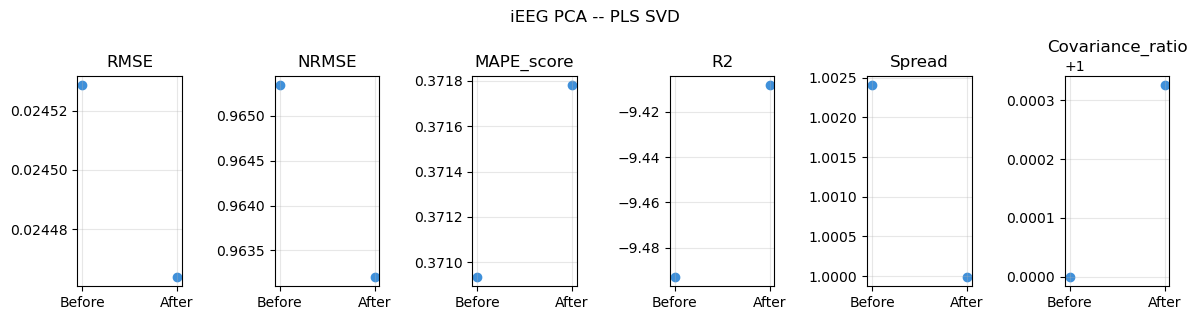

In [46]:
M, t, indices, rmse = affine_registration(A, B)
A_transformed = M @ A + t[:, None]

metrics_before_fold = compute_metrics(B,A)
metrics_after_fold = compute_metrics(B,A_transformed)

fig, axes = plt.subplots(1, 6,figsize=(12, 3))
before_mean = metrics_before_fold
after_mean = metrics_after_fold

for i, name in enumerate(metric_names):
    ax = axes[i]
    means = [before_mean[name],after_mean[name]]
    ax.scatter([0, 1],means)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Before", "After"])
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.tight_layout()

fig.suptitle('iEEG PCA -- PLS SVD', y=1.05)
plt.show()


In [47]:
M = np.asarray(M, dtype=float)
translation = np.asarray(t, dtype=float)
U, singular_values, Vt = np.linalg.svd(M)
det_M = np.linalg.det(M)
Q = U @ Vt
D = np.eye(3)

if np.linalg.det(Q) < 0:
    D[-1, -1] = -1
R_rotation = U @ D @ Vt
reflection_matrix = Vt.T @ D @ Vt
reflection_detected = det_M < 0
stretch_matrix = (Vt.T @ np.diag(singular_values) @ Vt)
scaling_percent = (singular_values - 1) * 100
cos_theta = (np.trace(R_rotation) - 1) / 2
cos_theta = np.clip(cos_theta,-1,1)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)
rotation_percent = (theta_deg / 180) * 100
std_data = np.std(A,axis=1,ddof=1)
std_data = np.where(std_data == 0,np.nan,std_data)
translation_percent = (np.abs(translation) / std_data) * 100
diag_stretch = np.diag(np.diag(stretch_matrix))
shear_matrix = (stretch_matrix - diag_stretch)
normalized_shear = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        if i != j:
            denom = np.sqrt(abs(stretch_matrix[i, i]* stretch_matrix[j, j]))
            if denom != 0:
                normalized_shear[i, j] = (shear_matrix[i, j]/ denom)
shear_xy = (abs(normalized_shear[0, 1]) * 100)
shear_xz = (abs(normalized_shear[0, 2]) * 100)
shear_yz = (abs(normalized_shear[1, 2]) * 100)
shear_percent = (np.linalg.norm(normalized_shear,ord="fro")/ np.sqrt(2)* 100)

df = pd.DataFrame({
    "metric": [
        "Scaling PC1",
        "Scaling PC2",
        "Scaling PC3",

        "Translation PC1",
        "Translation PC2",
        "Translation PC3",

        "Shear XY",
        "Shear XZ",
        "Shear YZ",

        "Rotation"
    ],

    "percentage": [
        abs(scaling_percent[0]),
        abs(scaling_percent[1]),
        abs(scaling_percent[2]),

        translation_percent[0],
        translation_percent[1],
        translation_percent[2],

        shear_xy,
        shear_xz,
        shear_yz,

        rotation_percent
    ]

})

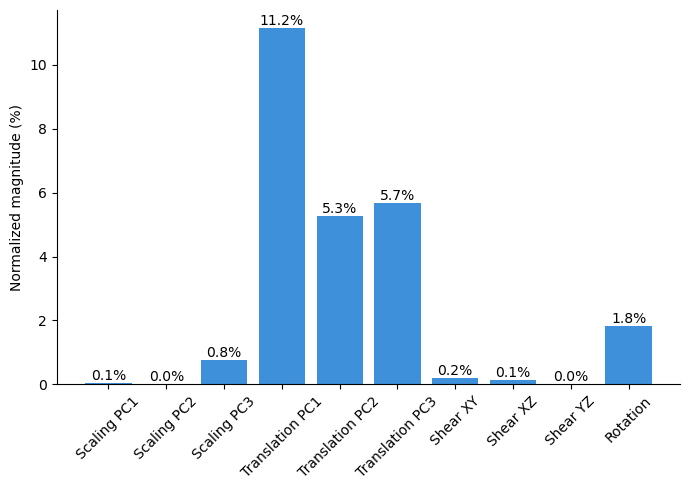

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(df['metric'],df['percentage'])
ax.set_ylabel('Normalized magnitude (%)')
ax.tick_params(axis='x', rotation=45)

# Values above bars
for bar, value in zip(bars, df['percentage']):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:.1f}%',
        ha='center',
        va='bottom'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

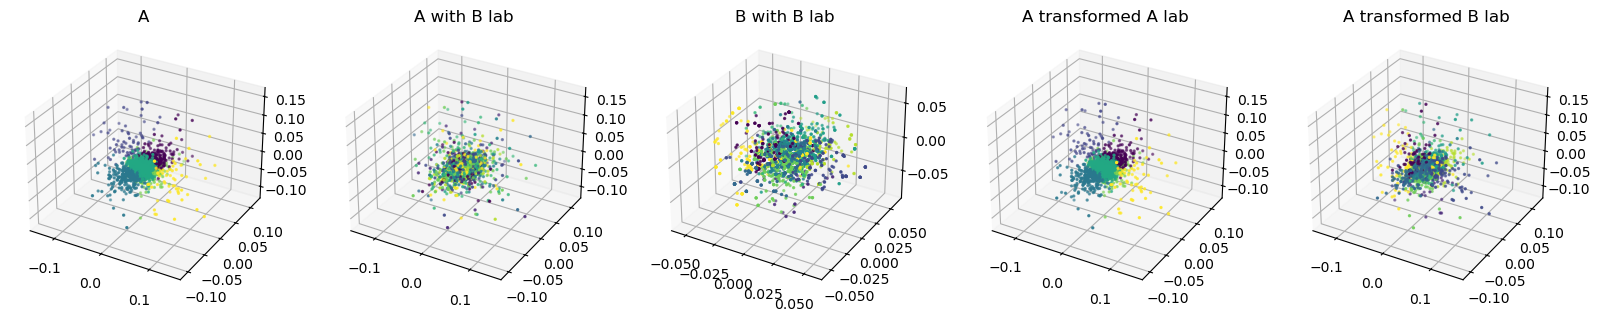

In [49]:
ig, axes = plt.subplots(1, 5,figsize=(20, 9), subplot_kw={'projection': '3d'})
title=['A', 'A with B lab', 'B with B lab', 'A transformed A lab', 'A transformed B lab']

for i, a in enumerate(axes):    
    a.set_title(title[i])

axes[0].scatter(A[0, :], A[1, :], A[2, :],  s=2,  c=df_label_all[f'ieeg'].values)
axes[1].scatter(A[ 0, :],  A[1,:], A[2,:],  s=2, c=df_label_all[f'meg'].values)
axes[2].scatter(B[ 0, indices],  B[1,indices], B[2,indices],  s=2, c=df_label_all[f'meg'].values[indices])
axes[3].scatter(A_transformed[0, :],  A_transformed[1, :], A_transformed[2, :], s=2, c=df_label_all[f'ieeg'].values) #df_label[f'meg_pc2'].values[indices])
axes[4].scatter(A_transformed[0, :],  A_transformed[1, :], A_transformed[2, :], s=2, c=df_label_all[f'meg'].values[indices])


In [50]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'A',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(A[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "db": davies_bouldin_score(A[pc,:].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "ch": calinski_harabasz_score(A[pc, :].reshape(-1, 1),df_labels[f"A_pc{pc}"])})
    res.append({"dataset": 'B',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "db": davies_bouldin_score(B[pc,:].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "ch": calinski_harabasz_score(B[pc, :].reshape(-1, 1),df_labels[f"B_pc{pc}"])})
    res.append({"dataset": 'B_est with Alab',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B_est[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "db": davies_bouldin_score(B_est[pc, :].reshape(-1, 1),df_labels[f"A_pc{pc}"]),
                "ch": calinski_harabasz_score(B_est[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"])})
    res.append({"dataset": 'B_est with Blab',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "db": davies_bouldin_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "ch": calinski_harabasz_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"])})


res_PLS= pd.DataFrame(res)

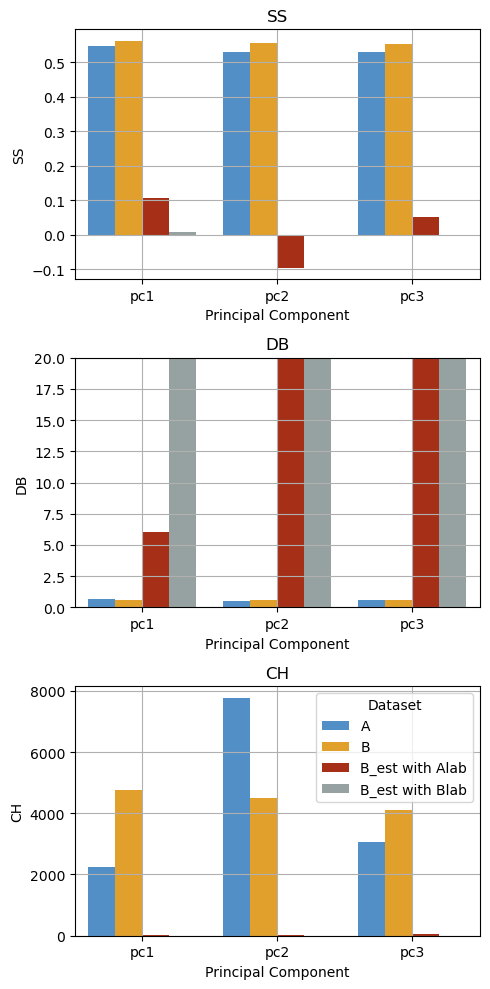

In [51]:
fig, axes = plt.subplots(3,1, figsize=(5,10))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=res_PLS,
        x='pc_lab',
        y=metric,
        hue='dataset',
        ax=ax
    )
    if metric == 'db' : ax.set_ylim(0, 20)
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper()) 
    ax.grid()
    ax.legend().remove()

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

In [52]:
A= cca_model.x_weights_.T[:3, :]
B= cca_model.y_weights_.T[:3, :]
coefficients, indices, rmse = polynomial_registration(A, B)
A_transformed = coefficients @ polynomial_features(A)

Mean NN distance: 0.013290991944431858
Median NN distance: 0.009868169725027222


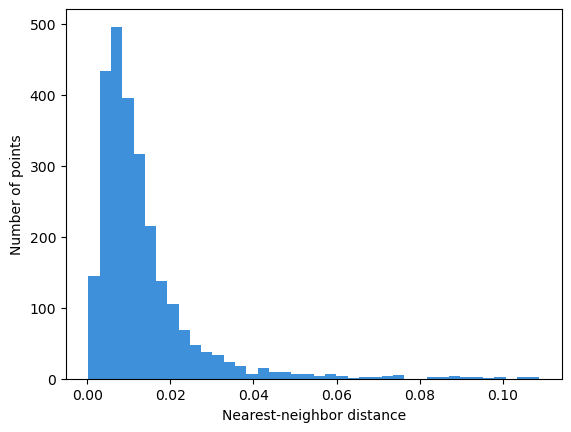

In [53]:
nn_distance = np.linalg.norm(A - B[:, indices],axis=0)
print("Mean NN distance:", nn_distance.mean())
print("Median NN distance:", np.median(nn_distance))
plt.hist(nn_distance, bins=40)

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Number of points")

plt.show()

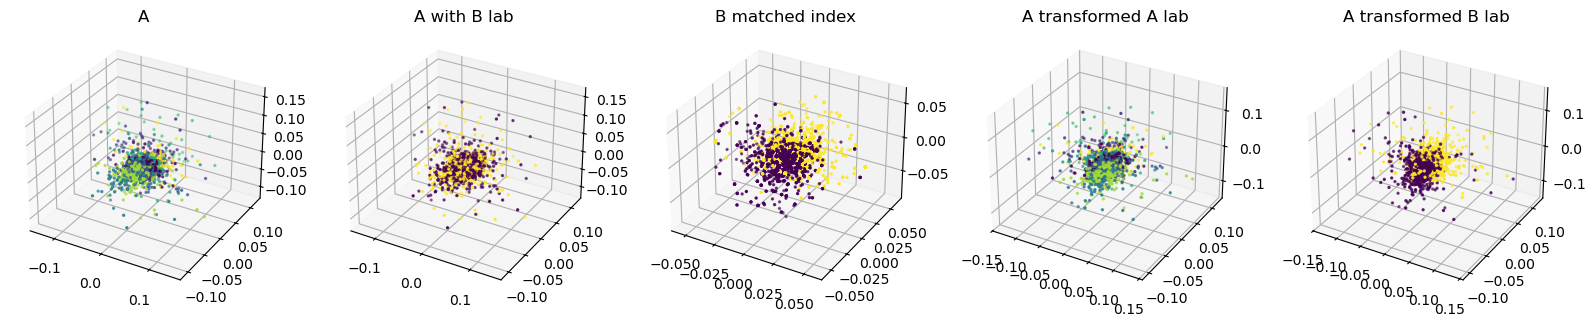

In [54]:
ig, axes = plt.subplots(1, 5,figsize=(20, 9), subplot_kw={'projection': '3d'})
title=['A', 'A with B lab', 'B matched index', 'A transformed A lab', 'A transformed B lab']
lab=str(1)
for i, a in enumerate(axes):    
    a.set_title(title[i])

axes[0].scatter(A[0, :], A[1, :], A[2, :],  s=2,  c=df_label[f'ieeg_pc{lab}'].values)
axes[1].scatter(A[ 0, :],  A[1,:], A[2,:],  s=2, c=df_label[f'meg_pc{lab}'].values)
axes[2].scatter(B[ 0, indices],  B[1,indices], B[2,indices],  s=2, c=df_label[f'meg_pc{lab}'].values[indices])
axes[3].scatter(A_transformed[0, :],  A_transformed[1, :], A_transformed[2, :], s=2, c=df_label[f'ieeg_pc{lab}'].values) 
axes[4].scatter(A_transformed[0, :],  A_transformed[1, :], A_transformed[2, :], s=2, c=df_label[f'meg_pc{lab}'].values[indices])


In [55]:
res =[]

for pc in range(3) : 
    res.append({"dataset": 'A',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(A[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "db": davies_bouldin_score(A[pc,:].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "ch": calinski_harabasz_score(A[pc, :].reshape(-1, 1),df_labels[f"A_pc{pc}"])})
    res.append({"dataset": 'B',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "db": davies_bouldin_score(B[pc,:].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "ch": calinski_harabasz_score(B[pc, :].reshape(-1, 1),df_labels[f"B_pc{pc}"])})
    res.append({"dataset": 'B_est with Alab',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B_est[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"]),
                "db": davies_bouldin_score(B_est[pc, :].reshape(-1, 1),df_labels[f"A_pc{pc}"]),
                "ch": calinski_harabasz_score(B_est[pc, :].reshape(-1, 1), df_labels[f"A_pc{pc}"])})
    res.append({"dataset": 'B_est with Blab',
                "pc_lab": f"pc{pc+1}",
                "ss": silhouette_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "db": davies_bouldin_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"]),
                "ch": calinski_harabasz_score(B_est[pc, :].reshape(-1, 1), df_labels[f"B_pc{pc}"])})


res_PLS= pd.DataFrame(res)

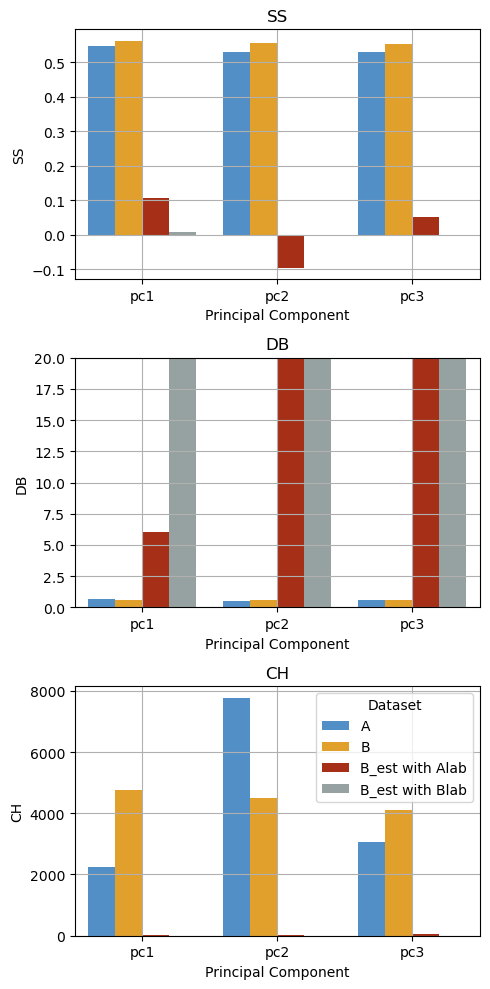

In [56]:
fig, axes = plt.subplots(3,1, figsize=(5,10))
metrics = ['ss', 'db', 'ch']
for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=res_PLS,
        x='pc_lab',
        y=metric,
        hue='dataset',
        ax=ax
    )
    if metric == 'db' : ax.set_ylim(0, 20)
    ax.set_title(metric.upper())
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(metric.upper()) 
    ax.grid()
    ax.legend().remove()

plt.tight_layout()
ax.legend(title='Dataset')
plt.show()

### analysis of the transformed


In [57]:
df=pd.DataFrame(regions_ieeg, columns =['regions'])
for i in range(3) : 
    df['Atr PC' +str(i)] = A_transformed[i, :]
    df['A PC' +str(i)] = A[i, :]
    df['B PC' +str(i)] = B[i, :]
    df['ieeg_pc' + str(i)] = df_label[f'ieeg_pc'+str(i)]
    df['meg_pc' + str(i)] = df_label[f'meg_pc'+str(i)]


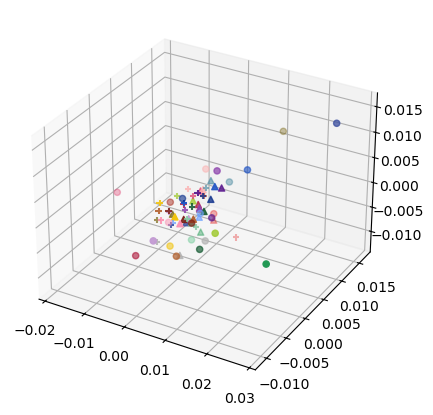

In [58]:
fig, axes = plt.subplots(figsize=(10, 5), subplot_kw={'projection': '3d'})
marker = ['^', '+', 'o']
for p, plot in enumerate(['Atr', 'A', 'B']) : 
    data = df.groupby('regions').median()
    axes.scatter(data.loc[:, plot + ' PC0'], data.loc[:, plot + ' PC1'], data.loc[:, plot + ' PC2'], c=[COL_REG[reg] for reg in data.index], marker=marker[p])



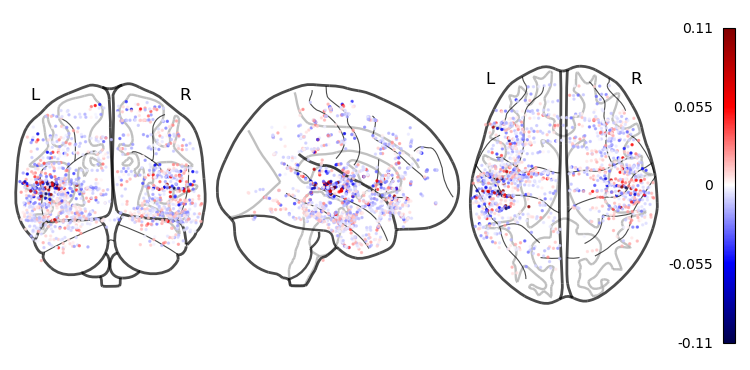

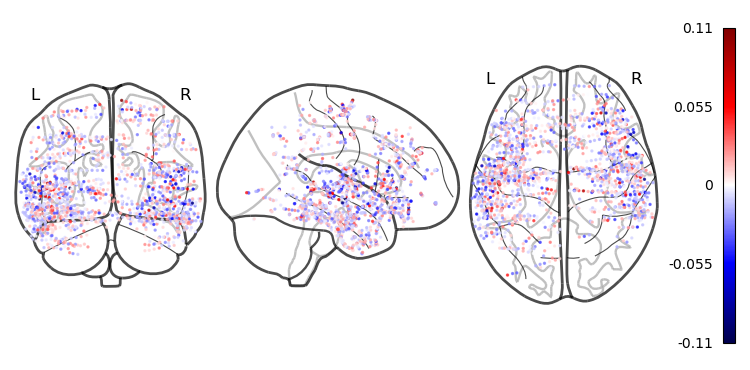

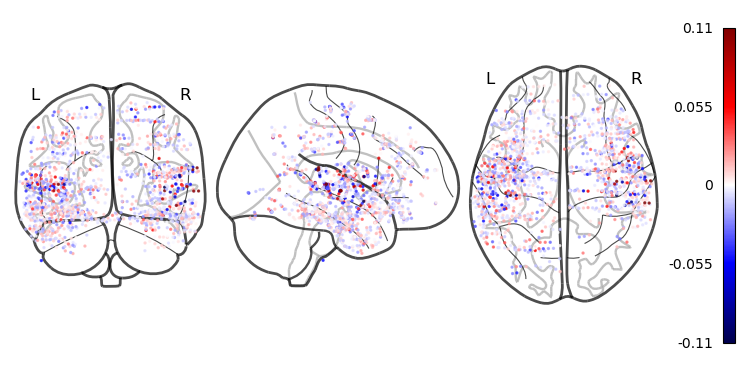

In [59]:
thr = CompoThr(df[['A PC'+str(i) for i in range(3)]].values)

for i in range(3):
    mask = np.where(abs(thr[:, i]) !=0, True, False)
    plotting.plot_markers(thr[mask, i],coord[mask]*1000,  node_cmap='seismic', node_vmin=-0.11, node_vmax=0.11, node_size=2)


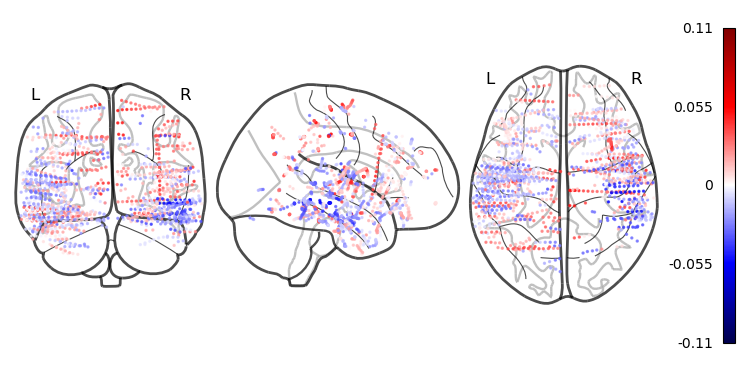

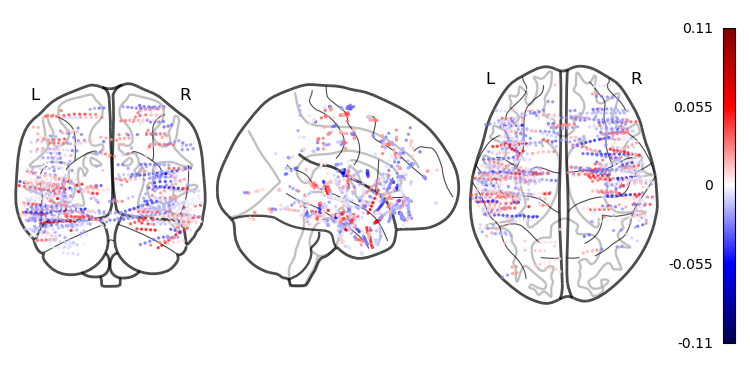

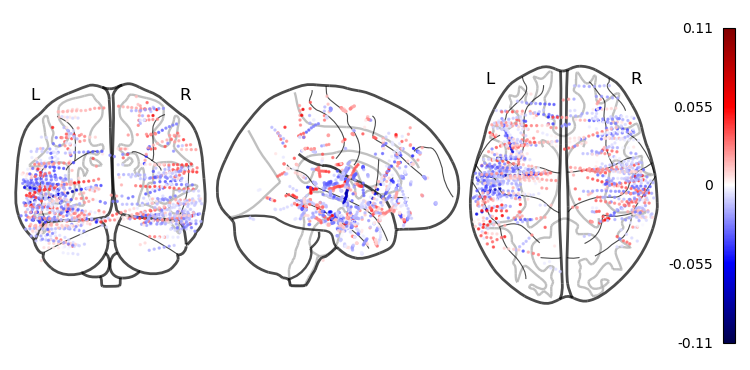

In [60]:
thr = CompoThr(df[['B PC'+str(i) for i in range(3)]].values)

for i in range(3):
    mask = np.where(abs(thr[:, i]) !=0, True, False)
    plotting.plot_markers(thr[mask, i],coord[mask]*1000,  node_cmap='seismic', node_vmin=-0.11, node_vmax=0.11, node_size=2)


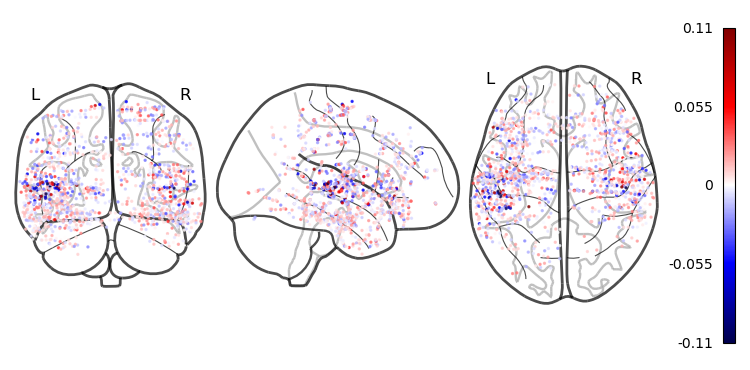

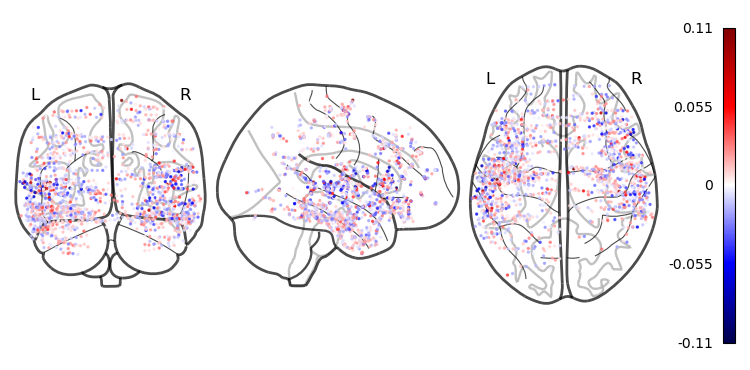

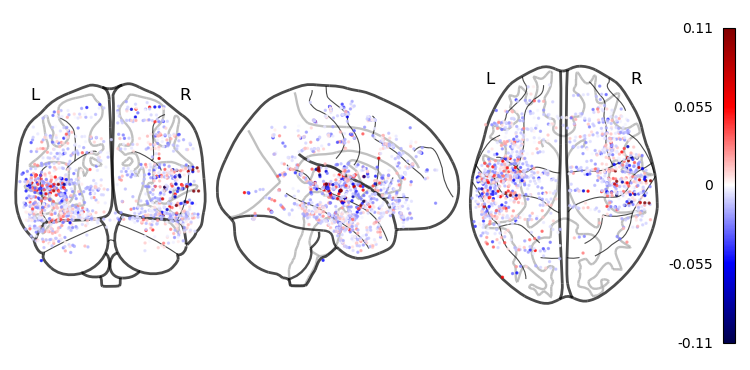

In [61]:
thr = CompoThr(df[['Atr PC'+str(i) for i in range(3)]].values)

for i in range(3):
    mask = np.where(abs(thr[:, i]) !=0, True, False)
    plotting.plot_markers(thr[mask, i],coord[mask]*1000,  node_cmap='seismic', node_vmin=-0.11, node_vmax=0.11, node_size=2)


# PLOT CONSIDERATION

In [205]:
import numpy as np
import nibabel as nib
from nilearn import datasets, image, plotting, surface
import hcp_utils as hcp
coords, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coords=np.array(coords)
coords = np.where(abs(coords) >100, coords/1000, coords)
coords = np.where(abs(coords) >100, coords/1000, coords)

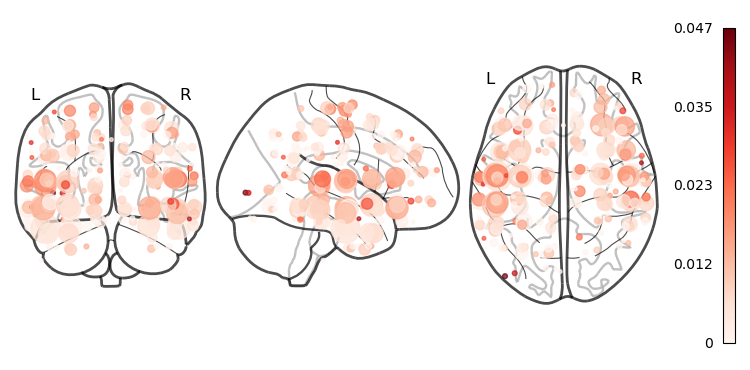

In [211]:
xyz = np.asarray(coords)  

values = np.abs(CompoThr(pca_ieeg.components_))[1, :]
grid_size = 20  # mm

x_edges = np.arange(
    np.floor(xyz[:, 0].min() / grid_size) * grid_size,
    np.ceil(xyz[:, 0].max() / grid_size) * grid_size + grid_size,
    grid_size
)

y_edges = np.arange(
    np.floor(xyz[:, 1].min() / grid_size) * grid_size,
    np.ceil(xyz[:, 1].max() / grid_size) * grid_size + grid_size,
    grid_size
)

z_edges = np.arange(
    np.floor(xyz[:, 2].min() / grid_size) * grid_size,
    np.ceil(xyz[:, 2].max() / grid_size) * grid_size + grid_size,
    grid_size
)

grid_xyz = []
grid_values = []
grid_n = []

for ix in range(len(x_edges) - 1):
    for iy in range(len(y_edges) - 1):
        for iz in range(len(z_edges) - 1):
            x_low, x_high = x_edges[ix], x_edges[ix + 1]
            y_low, y_high = y_edges[iy], y_edges[iy + 1]
            z_low, z_high = z_edges[iz], z_edges[iz + 1]
            mask_cell = (
                (xyz[:, 0] >= x_low) &
                (xyz[:, 0] <  x_high) &
                (xyz[:, 1] >= y_low) &
                (xyz[:, 1] <  y_high) &
                (xyz[:, 2] >= z_low) &
                (xyz[:, 2] <  z_high)
            )
            n_channels = np.sum(mask_cell)
            if n_channels == 0:
                continue
            mean_coord = np.mean(
                xyz[mask_cell],
                axis=0
            )
            mean_value = np.nanmean(
                values[mask_cell]
            )

            grid_xyz.append(mean_coord)
            grid_values.append(mean_value)
            grid_n.append(n_channels)

grid_xyz = np.asarray(grid_xyz)
grid_values = np.asarray(grid_values)
grid_n = np.asarray(grid_n)
plotting.plot_markers(
    grid_values,
    grid_xyz,
    node_cmap="Reds",
    node_vmin=0,
    node_size=2 + 5 * grid_n,
)

In [222]:
electrodes = np.asarray(coords)
#thr = CompoThr(cca_model.x_weights_.T[:3, :])[0, :]
values = np.asarray(abs(CompoThr(pca_ieeg.components_[:3, :])[2, :]))
#values = np.asarray(abs(cca_model.x_weights_[:, 2]))
pca_ieeg.components_
template = datasets.load_mni152_template(resolution=2)
shape = template.shape
affine = template.affine
ijk = np.indices(shape).reshape(3, -1).T
xyz = nib.affines.apply_affine(affine, ijk)

sigma = 4  # mm
numerator = np.zeros(len(xyz))
denominator = np.zeros(len(xyz))
for coord, value in zip(electrodes, values):
    d2 = np.sum((xyz - coord)**2, axis=1)
    weights = np.exp(-d2 / (2 * sigma**2))
    numerator += weights * value
    denominator += weights

In [223]:
smooth_values = numerator / (denominator + 1e-12)
#smooth_values[denominator < 0.05] = np.nan
volume = smooth_values.reshape(shape)
smooth_img = nib.Nifti1Image(volume,affine)
thr = np.mean(values) + np.std(values)

/tmp/ipykernel_3851/4060318378.py:5: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(hcp.mesh.inflated_left,
/tmp/ipykernel_3851/4060318378.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(hcp.mesh.inflated_right,


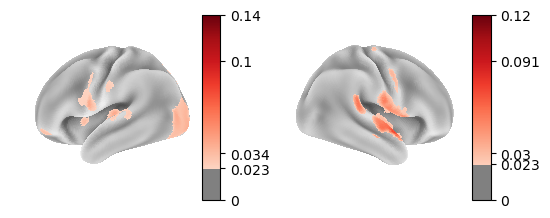

In [224]:
texture_left = surface.vol_to_surf(smooth_img, hcp.mesh.pial_left)
texture_right = surface.vol_to_surf(smooth_img, hcp.mesh.pial_right)

fig, axs = plt.subplots(1, 2, subplot_kw={'projection': '3d'})
plotting.plot_surf_stat_map(hcp.mesh.inflated_left, 
                            texture_left,
                            threshold=thr, 
                            hemi='left',
                            bg_map=hcp.mesh.sulc_left,
                            cmap='Reds', 
                            view='lateral', 
                            axes=axs[0], 
                            vmax=np.max(values))

plotting.plot_surf_stat_map(hcp.mesh.inflated_right, 
                            texture_right, 
                            threshold=thr, 
                            hemi='right',
                            bg_map=hcp.mesh.sulc_right, 
                            cmap='Reds', 
                            axes=axs[1], 
                            vmax=np.max(values)-np.std(values)) # oversaturation

plotting.show()